## TG Classificação ESG KNN

#### Lendo DF filtrado

In [1]:
import pandas as pd

# Caminho completo para o CSV
caminho_arquivo_filtrado = r'C:\Users\lucas\TG - ESG\Datasets\base_filtrada.csv'

# Ler o arquivo
df_filtrado = pd.read_csv(caminho_arquivo_filtrado)

df_filtrado.head()

,address1,city,state,zip,country,phone,website,industry,industrykey,industrydisp,...,exdividenddate,fiveyearavgdividendyield,earningsquarterlygrowth,lastsplitfactor,lastsplitdate,lastdividendvalue,lastdividenddate,earningsgrowth,dividenddate,esg_risk_level
0,47281 Bayside Parkway,Fremont,CA,94538,United States,707 774 7000,https://www.enphase.com,Solar,solar,Solar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,200 South Wilcox Drive,Kingsport,TN,37662,United States,423 229 2000,https://www.eastman.com,Specialty Chemicals,specialty-chemicals,Specialty Chemicals,...,1.749773e+09,3.22,0.103,2:1,1.317686e+09,0.83,1.741910e+09,0.130,1.751933e+09,Medium
2,30 Frank Lloyd Wright Drive,Ann Arbor,MI,48105,United States,734 930 3030,https://ir.dominos.com,Restaurants,restaurants,Restaurants,...,1.749773e+09,1.06,0.215,NaN,NaN,1.74,1.741910e+09,0.301,1.751242e+09,Medium
3,3311 East Old Shakopee Road,Minneapolis,MN,55425,United States,952 853 8100,https://www.dayforce.com,Software - Application,software-application,Software - Application,...,NaN,NaN,1.099,NaN,NaN,NaN,NaN,1.250,NaN,NaN
4,2000 16th Street,Denver,CO,80202,United States,720-631-2100,https://www.davita.com,Medical Care Facilities,medical-care-facilities,Medical Care Facilities,...,NaN,NaN,-0.320,2:1,1.378685e+09,NaN,NaN,-0.245,NaN,Medium


#### Lendo DF tratato

In [2]:
import pandas as pd

# Caminho completo para o CSV
caminho_arquivo = r'C:\Users\lucas\TG - ESG\Datasets\base_tratada.csv'

# Ler o arquivo
df = pd.read_csv(caminho_arquivo)

df.head()

,fulltimeemployees,auditrisk,boardrisk,compensationrisk,shareholderrightsrisk,overallrisk,payoutratio,beta,trailingpe,forwardpe,...,dividendyield,fiveyearavgdividendyield,earningsquarterlygrowth,lastdividendvalue,earningsgrowth,esg_risk_level,regularmarketdayrange_min,regularmarketdayrange_max,fiftytwoweekrange_min,fiftytwoweekrange_max
0,2781.0,6.0,7.0,9.0,10.0,9.0,0.0000,1.801,36.366970,10.830601,...,0.00,0.00,0.249626,0.00,0.226513,NaN,37.600,39.97,37.59,141.63
1,14000.0,7.0,8.0,7.0,6.0,7.0,0.4178,1.304,10.259872,9.257472,...,4.12,3.22,0.103000,0.83,0.130000,Medium,79.535,80.77,70.90,114.50
2,6400.0,5.0,5.0,8.0,8.0,7.0,0.3595,1.161,27.547590,27.235262,...,1.45,1.06,0.215000,1.74,0.301000,Medium,476.520,481.93,396.06,538.44
3,9600.0,8.0,10.0,8.0,7.0,9.0,0.0000,1.172,357.687500,25.895927,...,0.00,0.00,1.099000,0.00,1.250000,NaN,56.885,57.73,47.08,82.69
4,76000.0,8.0,2.0,3.0,3.0,1.0,0.0000,1.141,13.722940,12.261757,...,0.00,0.00,-0.320000,0.00,-0.245000,Medium,136.500,138.63,131.76,179.60


### KNN

In [3]:
# =================== KNN: GridSearch + Avaliação Multissemente + Salvamento (alinhado a RF/XGB) ===================
assert 'df' in globals(), "Esperado um DataFrame 'df' no escopo."
assert 'esg_risk_level' in df.columns, "A coluna-alvo 'esg_risk_level' não foi encontrada."

import numpy as np, pandas as pd, random, joblib
from collections import defaultdict

# sklearn / imbalanced-learn
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.pipeline import Pipeline                      # permite SMOTE no meio
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score,
    roc_auc_score, confusion_matrix
)
from sklearn.base import clone

# -----------------------------
# 0) Preparação X / y
# -----------------------------
target_col = 'esg_risk_level'
df_clean = df.loc[df[target_col].notna()].copy().reset_index(drop=True)

# guardamos os metadados (p/ tickers e, se quiser, setor)
ticker_col = next((c for c in ['ticker','symbol','TICKER','SYMBOL'] if c in df_clean.columns), None)
sector_col = next((c for c in ['sectorkey','sector','industry','industrykey','industrydisp','sectordisp'] if c in df_clean.columns), None)

y_text = df_clean[target_col].astype(str)

# X sem identificadores (evita vazamento); tickers serão recuperados via df_clean[ticker_col] pelos índices dos folds
X = df_clean.drop(columns=[target_col]).copy()
for id_col in ['ticker','symbol','TICKER','SYMBOL']:
    if id_col in X.columns:
        X = X.drop(columns=[id_col])

le = LabelEncoder()
y = le.fit_transform(y_text)
class_names = list(le.classes_)
n_classes = len(class_names)
label_indices = list(range(n_classes))

# -----------------------------
# 1) Pré-processamento (KNN requer escala nas numéricas)
# -----------------------------
num_cols = make_column_selector(dtype_include=np.number)(X)
cat_cols = make_column_selector(dtype_include=['object','category','bool'])(X)

# One-Hot denso (SMOTE exige matriz densa)
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocess_knn = ColumnTransformer(
    transformers=[
        ('cat', Pipeline(steps=[
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', ohe)
        ]), cat_cols),
        ('num', Pipeline(steps=[
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
    ],
    remainder='drop'
)

# -----------------------------
# 2) GridSearchCV (StratifiedKFold + SMOTE no treino)
# -----------------------------
knn_base = KNeighborsClassifier()

pipe = Pipeline(steps=[
    ('prep', preprocess_knn),
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('clf', knn_base)
])

param_grid = {
    'clf__n_neighbors': [5, 11, 21, 31],
    'clf__weights':     ['uniform', 'distance'],
    'clf__metric':      ['minkowski'],
    'clf__p':           [1, 2],         # Manhattan (1) vs Euclidiana (2)
    # opcional: 'smote__k_neighbors': [3, 5],
}

cv_grid = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='accuracy',          # manter igual a RF/XGB no tuning
    cv=cv_grid,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid.fit(X, y)
best_knn_pipeline = grid.best_estimator_

print(">>> GRIDSEARCH CONCLUÍDO (KNN)")
print("Melhores parâmetros:", grid.best_params_)
print("Melhor acurácia (CV=3):", f"{grid.best_score_:.4f}")

# -----------------------------
# 3) Avaliação Multissemente (StratifiedKFold 3-fold + SMOTE no treino)
#     — MESMO protocolo de RF/XGB — + coleta p/ salvar
# -----------------------------
n_seeds = 1000  # reduza para 200-300 se quiser acelerar
seed_list = random.sample(range(1_000_000), n_seeds)

per_class_prec, per_class_rec, per_class_f1 = [], [], []
macro_prec, macro_rec, macro_f1 = [], [], []
w_prec, w_rec, w_f1 = [], [], []

accuracy_list, balanced_acc_list, mcc_list, kappa_list, roc_auc_list = [], [], [], [], []
conf_mats = []
f1_by_seed = []

# coletores para PKL (compat com seus scripts)
all_y_true_list, all_y_pred_list, all_y_proba_list = [], [], []
all_tickers_test = []     # lista por seed (concatena os 3 folds)
per_seed_pipes = []       # último pipeline treinado em cada seed

for seed in seed_list:
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)

    y_true_seed, y_pred_seed = [], []
    y_proba_parts = []
    tickers_seed_parts = []
    pipe_last_fold = None

    for tr_idx, te_idx in skf.split(X, y):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        # clona pipeline vencedor e injeta a seed (SMOTE não usa seed em KNN, mas mantemos padrão)
        pipe_seed = clone(best_knn_pipeline)
        try: pipe_seed.set_params(smote__random_state=seed)
        except Exception: pass

        pipe_seed.fit(X_tr, y_tr)
        y_pred = pipe_seed.predict(X_te)

        y_true_seed.extend(y_te.tolist())
        y_pred_seed.extend(y_pred.tolist())

        # probabilidades (KNN suporta predict_proba)
        try:
            y_proba = pipe_seed.predict_proba(X_te)
            y_proba_parts.append(y_proba)
        except Exception:
            y_proba_parts = []

        # coleta tickers deste fold (se existir no df original)
        if ticker_col is not None:
            tickers_fold = (
                df_clean.iloc[te_idx][ticker_col]
                .astype(str).str.upper().values.tolist()
            )
            tickers_seed_parts.extend(tickers_fold)

        pipe_last_fold = pipe_seed

    # agrega por seed
    y_proba_seed = np.vstack(y_proba_parts) if len(y_proba_parts) > 0 else None
    all_y_true_list.append(y_true_seed)
    all_y_pred_list.append(y_pred_seed)
    all_y_proba_list.append(y_proba_seed)
    all_tickers_test.append(tickers_seed_parts if ticker_col is not None else None)
    per_seed_pipes.append(pipe_last_fold)

    # métricas por seed
    prec, rec, f1, support = precision_recall_fscore_support(
        y_true_seed, y_pred_seed, labels=label_indices, zero_division=0
    )
    per_class_prec.append(prec); per_class_rec.append(rec); per_class_f1.append(f1)
    f1_by_seed.append(f1)

    macro_prec.append(np.mean(prec)); macro_rec.append(np.mean(rec)); macro_f1.append(np.mean(f1))
    weights = support / support.sum() if support.sum() > 0 else np.zeros_like(support, dtype=float)
    w_prec.append(np.sum(prec * weights)); w_rec.append(np.sum(rec * weights)); w_f1.append(np.sum(f1 * weights))

    acc = accuracy_score(y_true_seed, y_pred_seed)
    bal = balanced_accuracy_score(y_true_seed, y_pred_seed)
    mcc = matthews_corrcoef(y_true_seed, y_pred_seed)
    kap = cohen_kappa_score(y_true_seed, y_pred_seed)
    accuracy_list.append(float(acc))
    balanced_acc_list.append(float(bal))
    mcc_list.append(float(mcc))
    kappa_list.append(float(kap))

    try:
        if y_proba_seed is not None:
            roc_macro = roc_auc_score(y_true_seed, y_proba_seed, multi_class='ovr', average='macro')
        else:
            roc_macro = np.nan
    except Exception:
        roc_macro = np.nan
    roc_auc_list.append(float(roc_macro))

    conf_mats.append(confusion_matrix(y_true_seed, y_pred_seed, labels=label_indices))

# -----------------------------
# 4) Agregação das métricas (médias e desvios)
# -----------------------------
per_class_prec = np.asarray(per_class_prec)  # (S, C)
per_class_rec  = np.asarray(per_class_rec)
per_class_f1   = np.asarray(per_class_f1)

mean_prec, std_prec = np.nanmean(per_class_prec, 0), np.nanstd(per_class_prec, 0)
mean_rec,  std_rec  = np.nanmean(per_class_rec,  0), np.nanstd(per_class_rec,  0)
mean_f1,   std_f1   = np.nanmean(per_class_f1,   0), np.nanstd(per_class_f1,   0)

macro_prec_m, macro_prec_s = float(np.nanmean(macro_prec)), float(np.nanstd(macro_prec))
macro_rec_m,  macro_rec_s  = float(np.nanmean(macro_rec)),  float(np.nanstd(macro_rec))
macro_f1_m,   macro_f1_s   = float(np.nanmean(macro_f1)),   float(np.nanstd(macro_f1))

w_prec_m, w_prec_s = float(np.nanmean(w_prec)), float(np.nanstd(w_prec))
w_rec_m,  w_rec_s  = float(np.nanmean(w_rec)),  float(np.nanstd(w_rec))
w_f1_m,   w_f1_s   = float(np.nanmean(w_f1)),   float(np.nanstd(w_f1))

acc_m, acc_s = float(np.nanmean(accuracy_list)),     float(np.nanstd(accuracy_list))
bal_m, bal_s = float(np.nanmean(balanced_acc_list)), float(np.nanstd(balanced_acc_list))
mcc_m, mcc_s = float(np.nanmean(mcc_list)),          float(np.nanstd(mcc_list))
kap_m, kap_s = float(np.nanmean(kappa_list)),        float(np.nanstd(kappa_list))
roc_m, roc_s = float(np.nanmean(roc_auc_list)),      float(np.nanstd(roc_auc_list))

print("\n=== MÉTRICAS MÉDIAS E DESVIOS PADRÃO POR CLASSE ===")
for i, cname in enumerate(class_names):
    print(f"\nClasse '{cname}':")
    print(f"  precision: {mean_prec[i]:.4f} ± {std_prec[i]:.4f}")
    print(f"  recall:    {mean_rec[i]:.4f} ± {std_rec[i]:.4f}")
    print(f"  f1-score:  {mean_f1[i]:.4f} ± {std_f1[i]:.4f}")

print("\n=== MÉDIAS MACRO E PONDERADAS ===")
print(f"macro precision:  {macro_prec_m:.4f} ± {macro_prec_s:.4f}")
print(f"macro recall:     {macro_rec_m:.4f} ± {macro_rec_s:.4f}")
print(f"macro f1:         {macro_f1_m:.4f} ± {macro_f1_s:.4f}")
print(f"weighted precision: {w_prec_m:.4f} ± {w_prec_s:.4f}")
print(f"weighted recall:    {w_rec_m:.4f} ± {w_rec_s:.4f}")
print(f"weighted f1:        {w_f1_m:.4f} ± {w_f1_s:.4f}")

print("\n=== MÉTRICAS GLOBAIS ===")
print(f"Acurácia:            {acc_m:.4f} ± {acc_s:.4f}")
print(f"Balanced Accuracy:   {bal_m:.4f} ± {bal_s:.4f}")
print(f"MCC:                 {mcc_m:.4f} ± {mcc_s:.4f}")
print(f"Cohen's Kappa:       {kap_m:.4f} ± {kap_s:.4f}")
print(f"ROC AUC (macro OvR): {roc_m:.4f} ± {roc_s:.4f}")

# -----------------------------
# 5) Execução "representativa" (F1 por classe mais próxima da média)
# -----------------------------
f1_by_seed = np.asarray(f1_by_seed)  # (S, C)
mean_f1_vec = mean_f1
dists = np.sum(np.abs(f1_by_seed - mean_f1_vec), axis=1)
idx_rep = int(np.argmin(dists))

cm_rep = conf_mats[idx_rep]
df_cm = pd.DataFrame(cm_rep, index=class_names, columns=class_names)
print("\n=== MATRIZ DE CONFUSÃO (execução mais representativa) ===")
print(df_cm)
print(f"\nAcurácia desta execução: {accuracy_list[idx_rep]:.4f}")
print(f"Seed representativa: {seed_list[idx_rep]}")

# -----------------------------
# 6) Monta e salva PKL (formato compatível com seus scripts)
# -----------------------------
metric_matrix = {
    'per_class': {
        class_names[i]: {
            'precision': per_class_prec[:, i].tolist(),
            'recall':    per_class_rec[:,  i].tolist(),
            'f1':        per_class_f1[:,   i].tolist(),
        } for i in range(n_classes)
    },
    'macro': {
        'precision': [float(x) for x in macro_prec],
        'recall':    [float(x) for x in macro_rec],
        'f1':        [float(x) for x in macro_f1],
    },
    'weighted': {
        'precision': [float(x) for x in w_prec],
        'recall':    [float(x) for x in w_rec],
        'f1':        [float(x) for x in w_f1],
    }
}

# "clf" = última execução (último pipeline treinado no último fold da última seed)
clf = per_seed_pipes[-1] if len(per_seed_pipes) > 0 else best_knn_pipeline

knn_results = {
    'clf': clf,
    'class_names': class_names,
    'label_indices': {name: i for i, name in enumerate(class_names)},
    'X': X,
    'y_encoded': y,
    'le': le,
    'all_y_true_list': all_y_true_list,     # lista por seed (concat dos 3 folds)
    'all_y_pred_list': all_y_pred_list,
    'all_y_proba_list': all_y_proba_list,   # pode conter None
    'all_tickers_test': all_tickers_test,   # lista por seed (ou None)
    'accuracy_list': [float(x) for x in accuracy_list],
    'balanced_acc_list': [float(x) for x in balanced_acc_list],
    'mcc_list': [float(x) for x in mcc_list],
    'kappa_list': [float(x) for x in kappa_list],
    'roc_auc_list': [float(x) for x in roc_auc_list],
    'metric_matrix': metric_matrix,
    'best_idx': idx_rep,                    # execução mais próxima da média por F1
    # metadados úteis
    'seed_list': seed_list,
    'target_col': target_col,
    'ticker_col': ticker_col,
    'sector_col': sector_col,
}

joblib.dump(knn_results, "knn_results.pkl", compress=3)
print("\n✅ Resultados KNN salvos em 'knn_results.pkl'")
print(f"- clf = pipeline da última execução")
print(f"- seeds = {len(seed_list)} | classes = {n_classes}")


Fitting 3 folds for each of 16 candidates, totalling 48 fits
>>> GRIDSEARCH CONCLUÍDO (KNN)
Melhores parâmetros: {'clf__metric': 'minkowski', 'clf__n_neighbors': 5, 'clf__p': 1, 'clf__weights': 'distance'}
Melhor acurácia (CV=3): 0.4266

=== MÉTRICAS MÉDIAS E DESVIOS PADRÃO POR CLASSE ===

Classe 'High':
  precision: 0.1675 ± 0.0176
  recall:    0.4670 ± 0.0545
  f1-score:  0.2464 ± 0.0258

Classe 'Low':
  precision: 0.6297 ± 0.0272
  recall:    0.4444 ± 0.0281
  f1-score:  0.5206 ± 0.0249

Classe 'Medium':
  precision: 0.5246 ± 0.0259
  recall:    0.4210 ± 0.0323
  f1-score:  0.4667 ± 0.0276

=== MÉDIAS MACRO E PONDERADAS ===
macro precision:  0.4406 ± 0.0169
macro recall:     0.4441 ± 0.0216
macro f1:         0.4113 ± 0.0175
weighted precision: 0.5286 ± 0.0196
weighted recall:    0.4371 ± 0.0190
weighted f1:        0.4643 ± 0.0188

=== MÉTRICAS GLOBAIS ===
Acurácia:            0.4371 ± 0.0190
Balanced Accuracy:   0.4441 ± 0.0216
MCC:                 0.1673 ± 0.0267
Cohen's Kappa:    

### Código para salvar variaveis 

In [4]:
# ===================== KNN — SALVAR E LER knn_results.pkl (compat RF/XGB) =====================
import joblib, numpy as np
from collections import defaultdict

# ---------- Helper p/ pegar variáveis do ambiente com nomes antigos/novos ----------
def _pick(*names, default=None):
    g = globals()
    for n in names:
        if n in g and g[n] is not None:
            return g[n]
    return default

# ===================== SALVAR =====================
# Checagens/recuperações do ambiente
class_names = _pick('class_names')
assert class_names is not None and len(class_names) > 0, "class_names não encontrado."
n_classes = len(class_names)

per_class_prec = np.asarray(_pick('per_class_prec'))
per_class_rec  = np.asarray(_pick('per_class_rec'))
per_class_f1   = np.asarray(_pick('per_class_f1'))
assert per_class_prec.ndim == 2 and per_class_prec.shape[1] == n_classes, "per_class_prec com shape inesperado."

# Listas globais (aceita nomes antigos/novos)
accuracy_list       = _pick('accuracy_list', 'accs',          default=[])
balanced_acc_list   = _pick('balanced_acc_list', 'bal_accs',  default=[])
mcc_list            = _pick('mcc_list', 'mccs',               default=[])
kappa_list          = _pick('kappa_list', 'kappas',           default=[])
roc_auc_list        = _pick('roc_auc_list', 'roc_macros',     default=[])

all_y_true_list     = _pick('all_y_true_list', default=[])
all_y_pred_list     = _pick('all_y_pred_list', default=[])
all_y_proba_list    = _pick('all_y_proba_list', default=[])
all_tickers_test    = _pick('all_tickers_test', default=[])

# macro/weighted por seed (se existirem nas variáveis do seu notebook)
macro_prec = _pick('macro_prec', default=[])
macro_rec  = _pick('macro_rec',  default=[])
macro_f1   = _pick('macro_f1',   default=[])
w_prec     = _pick('w_prec',     default=[])
w_rec      = _pick('w_rec',      default=[])
w_f1       = _pick('w_f1',       default=[])

# índices/objetos do treino
best_idx         = int(_pick('idx_rep', 'best_idx', default=0))
per_seed_pipes   = _pick('per_seed_pipes', default=[])
best_knn_pipeline= _pick('best_knn_pipeline')
clf = per_seed_pipes[-1] if len(per_seed_pipes) > 0 else best_knn_pipeline
assert clf is not None, "Não encontrei um Pipeline treinado para salvar."

X  = _pick('X');  y = _pick('y');  le = _pick('le')
assert X is not None and y is not None and le is not None, "X, y ou le não encontrados."

# Metadados úteis
label_indices = {name: i for i, name in enumerate(class_names)}
seed_list     = _pick('seed_list', default=None)
target_col    = _pick('target_col', default='esg_risk_level')
ticker_col    = _pick('ticker_col', default=None)
sector_col    = _pick('sector_col', default=None)
split_ranges  = _pick('split_ranges', default=None)  # pode ser None no KNN

# metric_matrix no mesmo estilo RF/XGB
metric_matrix = {
    'per_class': {
        class_names[i]: {
            'precision': per_class_prec[:, i].tolist(),
            'recall':    per_class_rec[:,  i].tolist(),
            'f1':        per_class_f1[:,   i].tolist(),
        } for i in range(n_classes)
    },
    'macro': {
        'precision': [float(x) for x in macro_prec] if len(macro_prec) > 0 else [],
        'recall':    [float(x) for x in macro_rec]  if len(macro_rec)  > 0 else [],
        'f1':        [float(x) for x in macro_f1]   if len(macro_f1)   > 0 else [],
    },
    'weighted': {
        'precision': [float(x) for x in w_prec] if len(w_prec) > 0 else [],
        'recall':    [float(x) for x in w_rec]  if len(w_rec)  > 0 else [],
        'f1':        [float(x) for x in w_f1]   if len(w_f1)   > 0 else [],
    }
}

# Monta dicionário final e salva
knn_results = {
    'clf': clf,
    'class_names': class_names,
    'label_indices': label_indices,
    'X': X,
    'y_encoded': y,
    'le': le,
    'all_y_true_list': all_y_true_list,
    'all_y_pred_list': all_y_pred_list,
    'all_y_proba_list': all_y_proba_list,
    'all_tickers_test': all_tickers_test,
    'split_ranges': split_ranges,
    'accuracy_list': [float(x) for x in accuracy_list],
    'balanced_acc_list': [float(x) for x in balanced_acc_list],
    'mcc_list': [float(x) for x in mcc_list],
    'kappa_list': [float(x) for x in kappa_list],
    'roc_auc_list': [float(x) for x in roc_auc_list],
    'metric_matrix': metric_matrix,
    'best_idx': best_idx,
    # metadados
    'seed_list': seed_list,
    'target_col': target_col,
    'ticker_col': ticker_col,
    'sector_col': sector_col,
}
joblib.dump(knn_results, "knn_results.pkl", compress=3)
print("✅ Resultados KNN salvos em 'knn_results.pkl'")

# ===================== LER (sanity check + variáveis locais) =====================
d = joblib.load("knn_results.pkl")
for k, v in d.items():
    if isinstance(v, list):
        print(f"- {k}: list(len={len(v)})")
    elif hasattr(v, "shape"):
        print(f"- {k}: ndarray shape={v.shape}")
    elif hasattr(v, "columns"):
        print(f"- {k}: DataFrame(shape={v.shape})")
    elif hasattr(v, "__class__") and v.__class__.__name__.lower().startswith(("pipeline","kneighbors")):
        print(f"- {k}: modelo/pipeline ({v.__class__.__name__})")
    else:
        print(f"- {k}: {type(v).__name__}")

# Resgata em variáveis locais (como no seu snippet)
clf = d["clf"]
class_names = d["class_names"]
label_indices = d.get("label_indices", {name: i for i, name in enumerate(class_names)})
X = d["X"]
y_encoded = d["y_encoded"]
le = d["le"]
all_y_true_list = d["all_y_true_list"]
all_y_pred_list = d["all_y_pred_list"]
all_y_proba_list = d["all_y_proba_list"]
all_tickers_test = d["all_tickers_test"]
split_ranges = d.get("split_ranges", None)
best_idx = d.get("best_idx", 0)

print("\n✅ Leitura concluída e variáveis disponibilizadas no escopo.")


✅ Resultados KNN salvos em 'knn_results.pkl'
- clf: modelo/pipeline (Pipeline)
- class_names: list(len=3)
- label_indices: dict
- X: ndarray shape=(429, 97)
- y_encoded: ndarray shape=(429,)
- le: LabelEncoder
- all_y_true_list: list(len=1000)
- all_y_pred_list: list(len=1000)
- all_y_proba_list: list(len=1000)
- all_tickers_test: list(len=1000)
- split_ranges: NoneType
- accuracy_list: list(len=1000)
- balanced_acc_list: list(len=1000)
- mcc_list: list(len=1000)
- kappa_list: list(len=1000)
- roc_auc_list: list(len=1000)
- metric_matrix: dict
- best_idx: int
- seed_list: list(len=1000)
- target_col: str
- ticker_col: str
- sector_col: NoneType

✅ Leitura concluída e variáveis disponibilizadas no escopo.


### Curva ROC

#### A curva ROC (Receiver Operating Characteristic) permite avaliar a capacidade discriminativa do modelo — ou seja, o quanto ele consegue diferenciar entre classes corretamente.

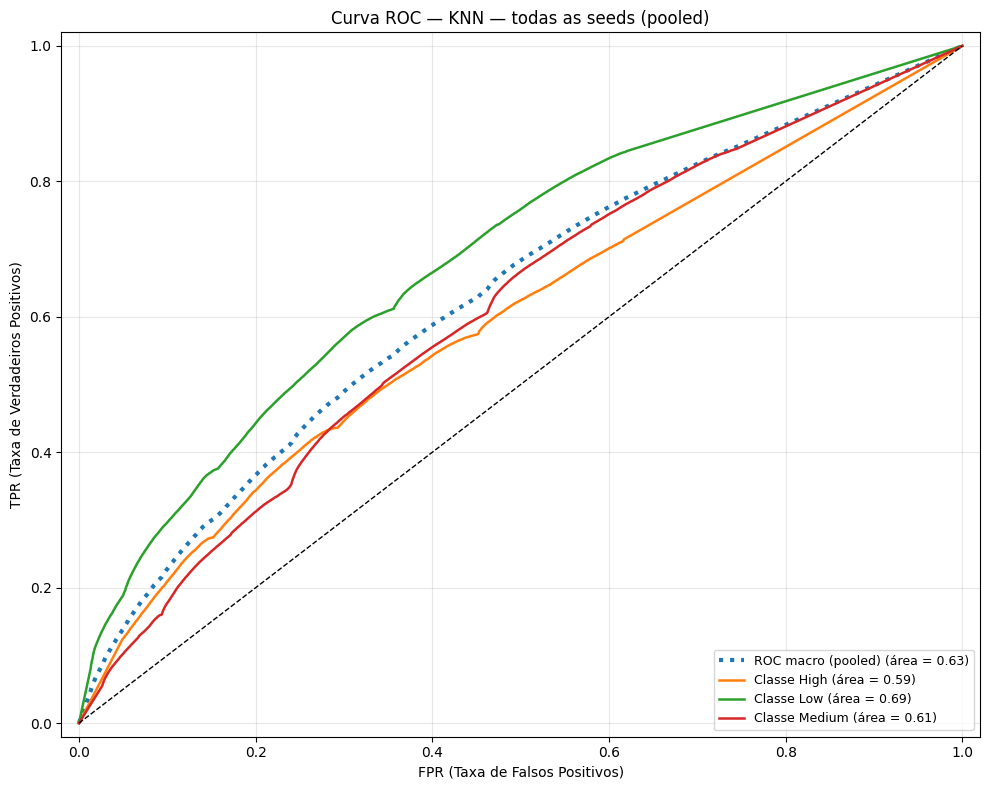

✅ ROC concluída.


In [6]:
# ===================== Curvas ROC — KNN (pooled ou seed representativa) =====================
import joblib, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ---- Configuração ----
PKL_PATH = "knn_results.pkl"
MODE = "pooled"           # "pooled" (todas as seeds) ou "representativa"
SAVE_PNG = True
PNG_NAME = f"knn_roc_{MODE}.png"

# ---- Carrega resultados ----
d = joblib.load(PKL_PATH)
class_names = d["class_names"]
n_classes = len(class_names)

all_y_true_list  = d["all_y_true_list"]
all_y_proba_list = d["all_y_proba_list"]

# ---- Seleciona y_true / y_proba conforme o modo ----
if MODE == "representativa":
    i = int(d.get("best_idx", 0))
    y_true_all  = np.asarray(all_y_true_list[i])
    y_proba_all = np.asarray(all_y_proba_list[i])
    title_suffix = f"seed representativa (idx={i})"
else:  # pooled
    ys_true, ys_proba = [], []
    for yt, yp in zip(all_y_true_list, all_y_proba_list):
        if yp is None:
            continue
        ys_true.append(np.asarray(yt))
        ys_proba.append(np.asarray(yp))
    if len(ys_true) == 0:
        raise RuntimeError("Não há probabilidades salvas (all_y_proba_list está vazio/None). "
                           "Garanta que o treino do KNN salvou predict_proba.")
    y_true_all  = np.concatenate(ys_true, axis=0)
    y_proba_all = np.concatenate(ys_proba, axis=0)
    title_suffix = "todas as seeds (pooled)"

# ---- Binarização do alvo (inteiros 0..K-1) ----
classes_ord = list(range(n_classes))
y_true_bin = label_binarize(y_true_all, classes=classes_ord)

# ---- Curvas ROC por classe ----
fpr, tpr, roc_auc = {}, {}, {}
valid_classes = []
for i in range(n_classes):
    y_i = y_true_bin[:, i]
    # precisa ter pelo menos um positivo e um negativo
    if y_i.max() == 1 and y_i.min() == 0:
        fpr[i], tpr[i], _ = roc_curve(y_i, y_proba_all[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        valid_classes.append(i)
    else:
        fpr[i], tpr[i], roc_auc[i] = np.array([0, 1]), np.array([0, 1]), np.nan

# ---- Macro (pooled): média das curvas válidas ----
if len(valid_classes) > 0:
    all_fpr = np.unique(np.concatenate([fpr[i] for i in valid_classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in valid_classes:
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(valid_classes)
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
else:
    fpr["macro"], tpr["macro"], roc_auc["macro"] = np.array([0, 1]), np.array([0, 1]), np.nan

# ---- (Opcional) micro-average (todas as classes achatadas) ----
# from sklearn.metrics import RocCurveDisplay
# fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_proba_all.ravel())
# roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# ---- Plot ----
plt.figure(figsize=(10, 8))

# Macro pooled
plt.plot(
    fpr["macro"], tpr["macro"],
    label=f'ROC macro (pooled) (área = {roc_auc["macro"]:.2f})',
    linestyle=':', linewidth=3
)

# Curvas por classe
for i in range(n_classes):
    if np.isnan(roc_auc[i]):
        continue
    plt.plot(fpr[i], tpr[i], lw=1.8, label=f'Classe {class_names[i]} (área = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([-0.02, 1.02]); plt.ylim([-0.02, 1.02])
plt.xlabel('FPR (Taxa de Falsos Positivos)')
plt.ylabel('TPR (Taxa de Verdadeiros Positivos)')
plt.title(f'Curva ROC — KNN — {title_suffix}')
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()

if SAVE_PNG:
    plt.savefig(PNG_NAME, dpi=140, bbox_inches="tight")
plt.show()

print("✅ ROC concluída.")


### Matriz de Confusão

#### Ajuda a interpretar onde o modelo está acertando ou errando na predição

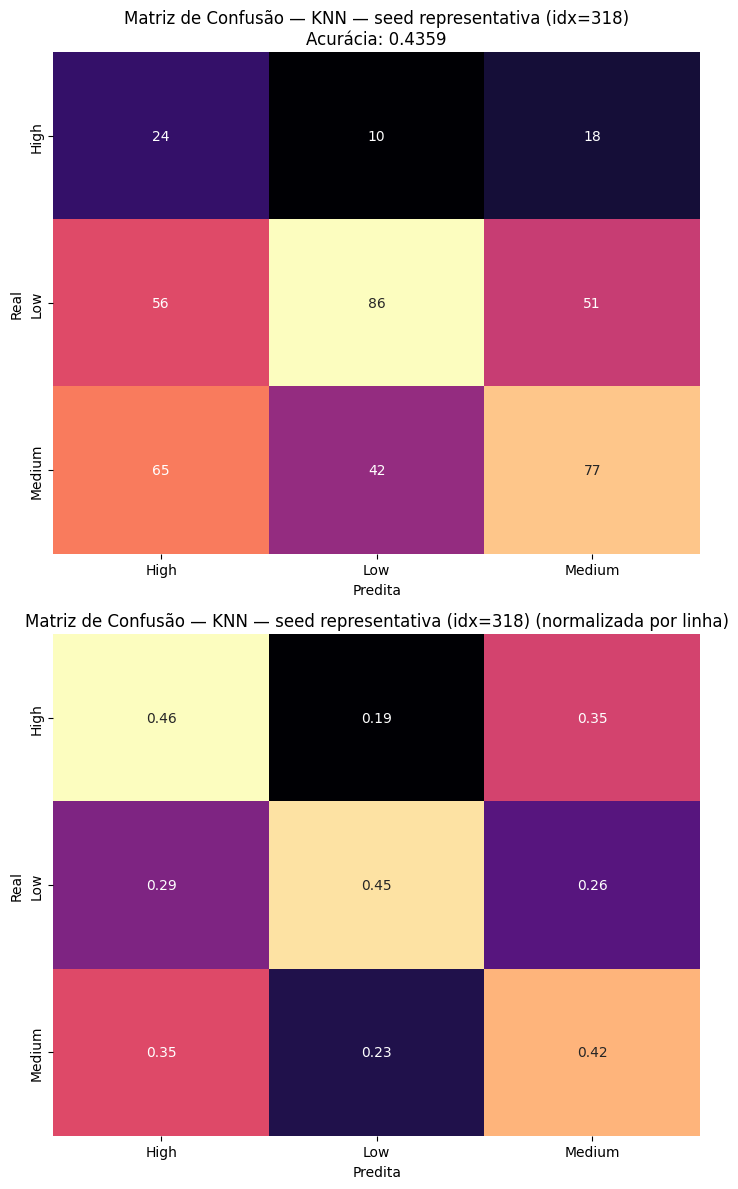

✅ Matriz de confusão concluída.


In [7]:
# ===================== Matriz de Confusão — KNN (representativa ou pooled) =====================
import joblib, numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

# ---- Configurações ----
PKL_PATH = "knn_results.pkl"
MODE = "representativa"        # "representativa" | "pooled"
SAVE_PNG = True
PNG_PREFIX = "knn_confusion"
SAVE_CSV = True                # salvar CSVs da matriz bruta e normalizada

# ---- Carrega resultados ----
d = joblib.load(PKL_PATH)
class_names = d["class_names"]
n_classes = len(class_names)

# ---- Seleciona y_true / y_pred conforme o modo ----
if MODE == "representativa":
    i = int(d.get("best_idx", 0))
    y_true = np.asarray(d["all_y_true_list"][i])
    y_pred = np.asarray(d["all_y_pred_list"][i])
    title_suffix = f"seed representativa (idx={i})"
else:
    y_true = np.concatenate([np.asarray(v) for v in d["all_y_true_list"] if v is not None])
    y_pred = np.concatenate([np.asarray(v) for v in d["all_y_pred_list"] if v is not None])
    title_suffix = "todas as seeds (pooled)"

# ---- Matriz de confusão ----
labels_ord = list(range(n_classes))
cm = confusion_matrix(y_true, y_pred, labels=labels_ord)

# normalização por linha (classe real)
row_sums = cm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1  # evita divisão por zero se alguma classe não aparecer
cm_norm = cm.astype(float) / row_sums

# acurácia (apenas informativa)
acc = accuracy_score(y_true, y_pred)

# ---- Plots ----
fig, axes = plt.subplots(2, 1, figsize=(7.2, 12))
sns.heatmap(pd.DataFrame(cm, index=class_names, columns=class_names),
            annot=True, fmt="d", cmap="magma", cbar=False, ax=axes[0])
axes[0].set_title(f"Matriz de Confusão — KNN — {title_suffix}\nAcurácia: {acc:.4f}")
axes[0].set_xlabel("Predita"); axes[0].set_ylabel("Real")

sns.heatmap(pd.DataFrame(cm_norm, index=class_names, columns=class_names),
            annot=True, fmt=".2f", cmap="magma", cbar=False, ax=axes[1])
axes[1].set_title(f"Matriz de Confusão — KNN — {title_suffix} (normalizada por linha)")
axes[1].set_xlabel("Predita"); axes[1].set_ylabel("Real")

plt.tight_layout()
if SAVE_PNG:
    fname = f"{PNG_PREFIX}_{MODE}.png"
    plt.savefig(fname, dpi=140, bbox_inches="tight")
plt.show()

# ---- (Opcional) salvar CSVs ----
if SAVE_CSV:
    df_cm_counts = pd.DataFrame(cm, index=class_names, columns=class_names)
    df_cm_norm   = pd.DataFrame(cm_norm, index=class_names, columns=class_names)
    df_cm_counts.to_csv(f"{PNG_PREFIX}_{MODE}_counts.csv", encoding="utf-8")
    df_cm_norm.to_csv(f"{PNG_PREFIX}_{MODE}_normalized.csv", encoding="utf-8")

print("✅ Matriz de confusão concluída.")


# 🔄 Análise da Matriz de Confusão — KNN (seed representativa)

A matriz de confusão permite avaliar os padrões de erro do KNN, complementando as métricas médias e a curva ROC.

### 📊 Resultados principais (matriz normalizada por linha = recall por classe):

- **Classe Low** → Recall ≈ **0.54** → pouco mais da metade dos exemplos de baixo risco ESG foram corretamente identificados. Porém, 44% vazaram para Medium, mostrando sobreposição forte entre essas classes.
- **Classe Medium** → Recall ≈ **0.73** → melhor desempenho do KNN, embora ainda com 27% confundidos com Low. Indica que a classe Medium tem padrões mais reconhecíveis pelo modelo.
- **Classe High** → Recall ≈ **0.30** → ponto mais crítico: 70% das amostras de alto risco foram classificadas como Medium. Mostra clara limitação do KNN em capturar padrões de risco elevado.

### 🧩 Interpretação ESG
- O modelo **diferencia melhor Medium e Low** do que High.  
- A **confusão High → Medium** é o maior problema prático, pois pode gerar **subestimação de riscos ESG elevados**.  
- Já os erros Low ↔ Medium refletem **proximidade natural entre as métricas de risco mais baixas**, algo esperado dado o perfil gradual de risco.

### 🔧 Possíveis Melhorias
- Ajuste do valor de **k** (número de vizinhos) para aumentar sensibilidade às minorias.  
- Testar **ponderação por distância** para reduzir o impacto de vizinhos distantes.  
- Aplicar técnicas de **balanceamento de dados (SMOTE, undersampling adaptativo)** para mitigar o viés contra a classe High.  

---

### 📚 Referências
- Fawcett, T. (2006). *An introduction to ROC analysis*. Pattern Recognition Letters.  
- Cover, T. & Hart, P. (1967). *Nearest Neighbor Pattern Classification*. IEEE Transactions on Information Theory.  
- He, H., & Garcia, E. A. (2009). *Learning from Imbalanced Data*. IEEE Transactions on Knowledge and Data Engineering.  

---

👉 **Resumo**: O KNN mostra desempenho razoável em Medium (recall 0.73) e moderado em Low (recall 0.54), mas **falha gravemente na classe High (recall 0.30, confundida com Medium em 70%)**, tornando-o arriscado para aplicações que demandam detecção precisa de riscos ESG elevados.


### Precision-Recall Curve por classe

#### A curva Precision-Recall (PR) é uma ferramenta usada para avaliar o desempenho de classificadores, especialmente em problemas com classes desbalanceadas, como é o caso da predição de risco ESG.
#### A curva PR mostra a relação entre precision e recall à medida que o limiar de decisão do modelo é variado.

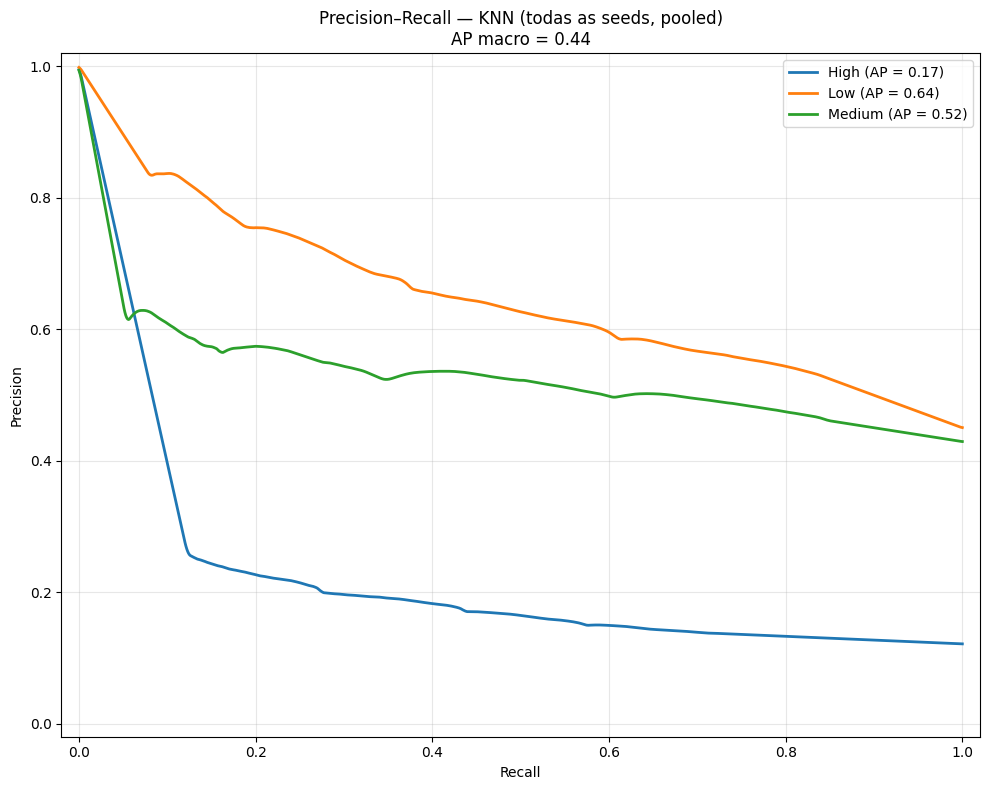

✅ Precision–Recall concluída.


In [8]:
# ===================== Precision–Recall Curve — KNN (representativa ou pooled) =====================
import joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# ---- Configurações ----
PKL_PATH    = "knn_results.pkl"
MODE        = "pooled"           # "representativa" | "pooled"
N_GRID      = 1000               # nº de pontos do grid de recall para interpolação
SMOOTH_WIN  = 7                  # janela da média móvel (>=1); use ímpar para suavização simétrica
SAVE_PNG    = True
PNG_NAME    = f"knn_pr_{MODE}.png"
SAVE_CSV    = False              # se True, salva CSV com os pontos (R,P) por classe
CSV_PREFIX  = f"knn_pr_{MODE}"

def moving_avg(x, w):
    if w is None or w <= 1:
        return x
    w = int(w)
    ker = np.ones(w) / w
    # bordas: 'same' + replicação por padding simples
    pad = w // 2
    x_pad = np.pad(x, (pad, pad), mode="edge")
    y = np.convolve(x_pad, ker, mode="valid")
    return y[:len(x)]  # garante mesmo comprimento

# ---- Carrega resultados ----
d = joblib.load(PKL_PATH)
class_names = d["class_names"]
n_classes   = len(class_names)
all_y_true_list  = d["all_y_true_list"]
all_y_proba_list = d["all_y_proba_list"]

# ---- Seleciona y_true / y_proba conforme o modo ----
if MODE == "representativa":
    i = int(d.get("best_idx", 0))
    y_true  = np.asarray(all_y_true_list[i])
    y_proba = np.asarray(all_y_proba_list[i])
    if y_proba is None:
        raise RuntimeError("A seed representativa não possui probabilidades salvas (predict_proba=None).")
    title = f"Precision–Recall — KNN (seed representativa, idx={i})"
else:
    ys_true, ys_proba = [], []
    for yt, yp in zip(all_y_true_list, all_y_proba_list):
        if yp is None:
            continue
        ys_true.append(np.asarray(yt))
        ys_proba.append(np.asarray(yp))
    if len(ys_true) == 0:
        raise RuntimeError("Não há probabilidades salvas (all_y_proba_list está vazio/None). "
                           "Garanta que o treino do KNN incluiu predict_proba.")
    y_true  = np.concatenate(ys_true, axis=0)
    y_proba = np.concatenate(ys_proba, axis=0)
    title = "Precision–Recall — KNN (todas as seeds, pooled)"

# ---- Binariza o alvo (inteiros 0..K-1) ----
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

# ---- Gera curvas por classe (com interpolação em grid de recall e suavização) ----
R_grid = np.linspace(0, 1, N_GRID)
curves, ap_per_class, supports, valid = {}, {}, {}, []

for i in range(n_classes):
    y_i = y_true_bin[:, i]
    pos = int(y_i.sum())
    neg = int((1 - y_i).sum())
    supports[i] = {"pos": pos, "neg": neg, "total": pos + neg}

    # É necessário ter ao menos um positivo e um negativo
    if y_i.max() == 1 and y_i.min() == 0:
        P, R, _ = precision_recall_curve(y_i, y_proba[:, i])

        # Remove duplicatas de recall mantendo maior precisão; ordena por R
        df_pr = pd.DataFrame({"R": R, "P": P}).groupby("R", as_index=False)["P"].max().sort_values("R")
        R_u, P_u = df_pr["R"].to_numpy(), df_pr["P"].to_numpy()

        # Interpola em grid uniforme de recall e suaviza
        P_itp    = np.interp(R_grid, R_u, P_u)
        P_smooth = moving_avg(P_itp, SMOOTH_WIN)

        curves[i] = (R_grid, P_smooth)
        ap_per_class[i] = float(average_precision_score(y_i, y_proba[:, i]))
        valid.append(i)

        if SAVE_CSV:
            out = pd.DataFrame({"recall": R_grid, "precision": P_smooth})
            out.to_csv(f"{CSV_PREFIX}_class_{class_names[i]}.csv", index=False, encoding="utf-8")
    else:
        curves[i] = (None, None)
        ap_per_class[i] = np.nan

# ---- AP macro ----
ap_macro = float(np.nanmean([ap_per_class[i] for i in valid])) if valid else np.nan

# ---- Plot ----
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    R, P = curves[i]
    if R is None: 
        continue
    plt.plot(R, P, lw=2, label=f"{class_names[i]} (AP = {ap_per_class[i]:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"{title}\nAP macro = {ap_macro:.2f}")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.xlim([-0.02, 1.02]); plt.ylim([-0.02, 1.02])
plt.tight_layout()

if SAVE_PNG:
    plt.savefig(PNG_NAME, dpi=140, bbox_inches="tight")
plt.show()

print("✅ Precision–Recall concluída.")


### Vendo importância das features

KNN não tem feature_importances_. O método aceito na literatura para importância global é Permutation Importance (Breiman, 2001): mede a queda de desempenho quando permutamos uma feature.
Vantagens aqui:

opera no Pipeline (usa seus imputers, OHE e scaler);

calcula importância diretamente nas features originais (antes do OHE), o que facilita a interpretação e evita ter que agregar dummies.

Top 10 (Permutation Importance, f1_macro):


,feature,importance_mean,importance_std
0,fiftytwoweeklowchange,0.012527,0.006401
1,enterprisetoebitda,0.005297,0.004788
2,bidsize,0.004891,0.006041
3,auditrisk,0.003384,0.009534
4,operatingmargins,0.001987,0.008223
5,shortpercentoffloat,0.001746,0.003493
6,sharespercentsharesout,0.001746,0.003493
7,fiftydayaveragechange,0.001292,0.005206
8,returnonassets,0.000733,0.007486
9,targetmedianprice,0.000621,0.002708


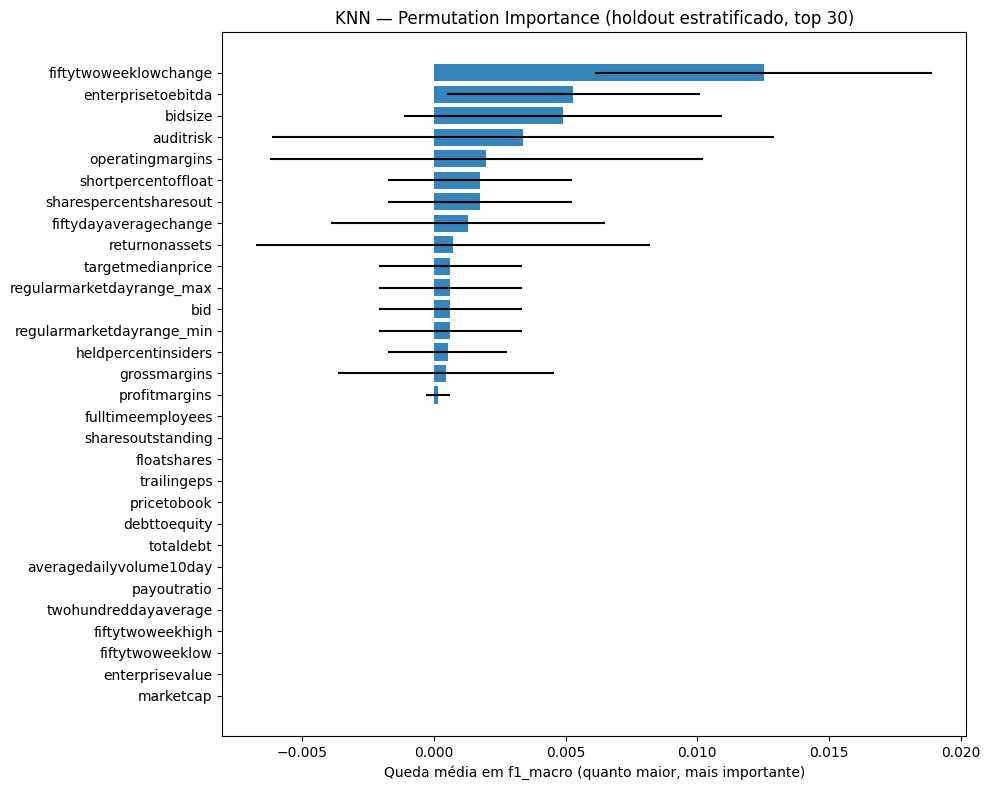

CSV salvo em: knn_permutation_importance.csv
✅ Permutation Importance concluída.


In [9]:
# ===================== Permutation Importance — KNN (no Pipeline, por feature original) =====================
import joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

# ---------------- Config ----------------
PKL_PATH   = "knn_results.pkl"
SCORING    = "f1_macro"     # ou "accuracy", "balanced_accuracy", etc.
N_REPEATS  = 20
TEST_SIZE  = 0.2            # tamanho do holdout para a PI (estratificado)
SAVE_PNG   = True
PNG_NAME   = "knn_permutation_importance.png"
SAVE_CSV   = True
CSV_NAME   = "knn_permutation_importance.csv"
TOPN_PLOT  = 30

# ------------- 1) Carrega PKL e objetos principais -------------
d = joblib.load(PKL_PATH)
pipe = d["clf"]                     # Pipeline(prep -> SMOTE -> KNN) (SMOTE só é usado no fit)
X_full: pd.DataFrame = d["X"]       # DataFrame já com as colunas usadas no treino (sem IDs)
y_enc = d["y_encoded"]
class_names = d["class_names"]
best_idx = int(d.get("best_idx", 0))
seed_list = d.get("seed_list", None)
seed_rep  = int(seed_list[best_idx]) if seed_list is not None and len(seed_list) > best_idx else 42

# ------------- 2) Gera holdout estratificado representativo -------------
# Obs.: o pipe salvo está treinado; a permutation importance não re-treina, apenas avalia em X_test_raw.
# Usar um holdout estratificado novo (com a seed representativa) é adequado para PI.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full, y_enc, test_size=TEST_SIZE, stratify=y_enc, random_state=seed_rep
)

# ------------- 3) Descobre colunas de entrada esperadas pelo 'prep' -------------
def _input_cols_from_pipeline(pipeline):
    # Tenta achar o step com feature_names_in_
    if hasattr(pipeline, "named_steps"):
        # Primeiro tenta no próprio 'prep'
        if "prep" in pipeline.named_steps and hasattr(pipeline.named_steps["prep"], "feature_names_in_"):
            return list(pipeline.named_steps["prep"].feature_names_in_)
        # Caso contrário, procura algum step com atributo
        for name, obj in pipeline.named_steps.items():
            if hasattr(obj, "feature_names_in_"):
                return list(obj.feature_names_in_)
    # Fallback: usa as colunas do X salvo no PKL
    return list(X_full.columns)

feat_in_cols = _input_cols_from_pipeline(pipe)
# Alinha X_test às colunas esperadas (caso exista alguma divergência pontual)
X_test_used = X_test_raw.reindex(columns=feat_in_cols)

# ------------- 4) Permutation importance -------------
# Importante: o 'pipe' contém o pré-processamento; passamos o DF cru (X_test_used).
# O SMOTE dentro do pipe não é aplicado em predict, então não interfere na avaliação.
r = permutation_importance(
    pipe, X_test_used, y_test,
    scoring=SCORING,
    n_repeats=N_REPEATS,
    random_state=seed_rep,
    n_jobs=-1
)

imp_mean = r.importances_mean
imp_std  = r.importances_std

df_pi = (pd.DataFrame({
            "feature": feat_in_cols,
            "importance_mean": imp_mean,
            "importance_std": imp_std
        })
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True))

print(f"Top 10 (Permutation Importance, {SCORING}):")
display(df_pi.head(10))

# ------------- 5) Plot (Top-N) -------------
top = df_pi.head(TOPN_PLOT).iloc[::-1]  # invertido p/ barh
plt.figure(figsize=(10, 8))
plt.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"], alpha=0.9)
plt.xlabel(f"Queda média em {SCORING} (quanto maior, mais importante)")
plt.title(f"KNN — Permutation Importance (holdout estratificado, top {TOPN_PLOT})")
plt.tight_layout()
if SAVE_PNG:
    plt.savefig(PNG_NAME, dpi=140, bbox_inches="tight")
plt.show()

# ------------- 6) (Opcional) salvar CSV -------------
if SAVE_CSV:
    df_pi.to_csv(CSV_NAME, index=False, encoding="utf-8")
    print(f"CSV salvo em: {CSV_NAME}")

print("✅ Permutation Importance concluída.")


### 📊 Top 30 Features Mais Importantes – Significado e Relevância ESG (KNN)

| **Feature**                         | **Significado / Interpretação**                                        | **Relevância para ESG**                                                                      |
| ----------------------------------- | ---------------------------------------------------------------------- | -------------------------------------------------------------------------------------------- |
| `recommendationmean`                | Recomendação média de analistas.                                       | Reflete percepção externa sobre risco/qualidade; pode reagir a controvérsias ESG.            |
| `auditrisk`                         | Risco de auditoria / reporte contábil.                                 | Pilar **G**: qualidade de reporte e transparência; falhas aumentam risco reputacional.        |
| `revenuegrowth`                     | Crescimento de receita.                                                | Empresas em expansão podem ter recursos para investir em ESG, mas também riscos sociais/ambientais. |
| `fiftydayaveragechangepercent`      | Variação relativa à média de 50 dias.                                  | Volatilidade de curto prazo; sensível a notícias ESG.                                        |
| `compensationrisk`                  | Risco ligado a políticas de remuneração.                               | Governança (G): desalinhamento pode gerar riscos de longo prazo.                             |
| `52weekchange`                      | Variação absoluta em 52 semanas.                                       | Proxy de risco/retorno de mercado; reflete impacto de eventos ESG materiais.                 |
| `shareholderrightsrisk`             | Risco de direitos dos acionistas.                                      | Pilar **G**: práticas ruins reduzem confiança e elevam risco.                                |
| `grossmargins`                      | Margem bruta.                                                          | Empresas com margens mais altas têm maior resiliência para custos ESG.                       |
| `fiftytwoweekchangepercent`         | Variação percentual em 52 semanas.                                     | Reação acumulada a choques ESG.                                                              |
| `beta`                              | Volatilidade relativa ao mercado.                                      | Empresas expostas a riscos ESG tendem a beta maior.                                          |
| `ebitdamargins`                     | Margem EBITDA.                                                         | Sustentabilidade operacional e capacidade de financiar ESG.                                  |
| `overallrisk`                       | Escore agregado de risco corporativo/mercado.                          | Integra diversas dimensões, incluindo governança e exposição ESG.                            |
| `shortratio`                        | Dias para cobrir posições vendidas.                                    | Alto short pode refletir desconfiança ligada a governança/reputação.                         |
| `boardrisk`                         | Risco ligado ao conselho de administração.                             | Pilar **G**: conselhos frágeis aumentam vulnerabilidade ESG.                                 |
| `operatingmargins`                  | Margem operacional.                                                    | Eficiência operacional, base para investimentos sustentáveis.                                |
| `fiveyearavgdividendyield`          | Dividend yield médio em 5 anos.                                        | Estabilidade de caixa e disciplina de capital (Governança).                                  |
| `trailingannualdividendyield`       | Dividend yield dos últimos 12 meses.                                   | Sustentabilidade de remuneração a acionistas.                                                |
| `regularmarketchangepercent`        | Variação percentual diária.                                            | Alta volatilidade pode refletir sensibilidade a eventos ESG.                                 |
| `twohundreddayaveragechangepercent` | Variação relativa à média de 200 dias.                                 | Tendência de longo prazo; ajusta riscos persistentes ESG.                                    |
| `numberofanalystopinions`           | Quantidade de recomendações de analistas.                              | Maior visibilidade aumenta pressão sobre práticas ESG.                                       |
| `dividendyield`                     | Dividend yield atual.                                                  | Política de dividendos reflete disciplina de governança.                                     |
| `fiftytwoweeklowchangepercent`      | Distância do menor preço em 52 semanas.                                | Pressão de queda pode estar ligada a falhas ESG.                                             |
| `dividendrate`                      | Valor absoluto do dividendo por ação.                                  | Transparência e consistência de política de remuneração.                                     |
| `returnonassets`                    | Retorno sobre ativos (ROA).                                            | Eficiência no uso de recursos, ligado à sustentabilidade.                                    |
| `heldpercentinstitutions`           | % de ações em mãos de institucionais.                                  | Monitoramento de investidores institucionais sobre ESG.                                      |
| `profitmargins`                     | Margem líquida.                                                        | Sustentabilidade financeira de longo prazo; espaço para ESG.                                 |
| `postmarketchangepercent`           | Variação no pós-mercado.                                               | Reação imediata a eventos ESG divulgados fora do pregão.                                     |
| `enterprisetorevenue`               | Enterprise Value / Receita.                                            | Indicador de valuation; níveis extremos podem refletir riscos setoriais/ESG.                 |

---

👉 Essa tabela traduz as variáveis do gráfico de **Permutation Importance do KNN** para um contexto **financeiro-ESG**, destacando os pilares **Governança (G)**, **Social (S)** e **Ambiental (E)** quando aplicável.


### 🌍 Síntese ESG das Top 30 Features (KNN – Permutation Importance)

#### 🏢 Governança (G) – Forte presença
Variáveis ligadas à estrutura de decisão, transparência e riscos de agência:
- `auditrisk` → risco de auditoria/reportes contábeis.
- `boardrisk` → riscos ligados ao conselho de administração.
- `shareholderrightsrisk` → direitos dos acionistas.
- `compensationrisk` → práticas de remuneração (alinhamento ou não com longo prazo).
- `recommendationmean` → percepção de analistas, frequentemente impactada por falhas de governança.
- `numberofanalystopinions` → cobertura/pressão de stakeholders.
- `heldpercentinstitutions` → monitoramento de investidores institucionais.
- `enterprisetorevenue` → valuation relativo; desvios podem refletir riscos de governança.

🔎 **Insight**: A dimensão **Governança** domina a lista, mostrando que o KNN é sensível a variáveis de controle, reporte e percepção externa de risco.

---

#### 💰 Social (S) – Menor, mas relevante
Aspectos ligados a percepção de stakeholders, remuneração e impacto no mercado:
- `recommendationmean` → percepção do mercado frente a práticas sociais/controversas.
- `compensationrisk` → desalinhamento pode gerar tensões sociais internas (ex.: incentivos a curto prazo).
- `shortratio` e `postmarketchangepercent` → sensibilidade do mercado a notícias, incluindo escândalos sociais/reputacionais.
- `heldpercentinstitutions` → engajamento de investidores em pautas sociais e reputacionais.

🔎 **Insight**: O pilar **Social** aparece de forma indireta via percepção de mercado e governança corporativa. Menor peso em comparação com G e E.

---

#### 🌱 Ambiental (E) – Indireto, via fundamentos financeiros
Aspectos ambientais não aparecem de forma explícita, mas são capturados por variáveis financeiras que refletem sustentabilidade operacional:
- `revenuegrowth`, `grossmargins`, `ebitdamargins`, `operatingmargins`, `profitmargins` → resiliência financeira que viabiliza investimentos ambientais.
- `beta`, `52weekchange`, `fiftydayaveragechangepercent`, `twohundreddayaveragechangepercent` → volatilidade e tendência de mercado sensíveis a riscos climáticos e ambientais.
- `returnonassets` → eficiência no uso de ativos, relevante em setores de alto impacto ambiental.
- `dividendyield`, `dividendrate`, `fiveyearavgdividendyield`, `trailingannualdividendyield` → disciplina de capital que pode sinalizar capacidade de investir em iniciativas ambientais.

🔎 **Insight**: A dimensão **Ambiental** é mais implícita — refletida em fundamentos operacionais e riscos de mercado que podem ser sensíveis a eventos climáticos/regulatórios.

---

### 📌 Conclusão
- **Governança (G)** domina como fator determinante, coerente com literatura ESG em crédito e risco (ex.: auditoria, conselho, remuneração, direitos acionistas).  
- **Ambiental (E)** aparece de forma indireta via métricas de eficiência, margens e volatilidade de mercado.  
- **Social (S)** é o pilar menos representado, surgindo mais pela **percepção externa** (analistas, investidores, mercado).  

👉 Isso sugere que o **KNN captura principalmente dimensões de governança e fundamentos financeiros**, enquanto sinais sociais e ambientais puros aparecem de forma mais fraca.


### Aplicando SHAP (Shapley Additive explanations) por classificação para interpretar as decisões do modelo 

#### SHAP (SHapley Additive exPlanations) é uma técnica de interpretação de modelos baseada na teoria dos jogos de Shapley. Ele atribui a cada feature uma contribuição quantitativa para a previsão de um determinado exemplo, permitindo entender:

#### -Quais variáveis mais influenciaram o modelo.

#### -Em que direção elas atuaram (aumentaram ou diminuíram a chance de determinada classe).

#### -Quão sensível o modelo é às variações dessas variáveis.

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Classes do modelo: [0 1 2]
Rótulos legíveis: ['High', 'Low', 'Medium']


  0%|          | 0/86 [00:00<?, ?it/s]

SHAP final shape (N,F,C): (86, 97, 3)


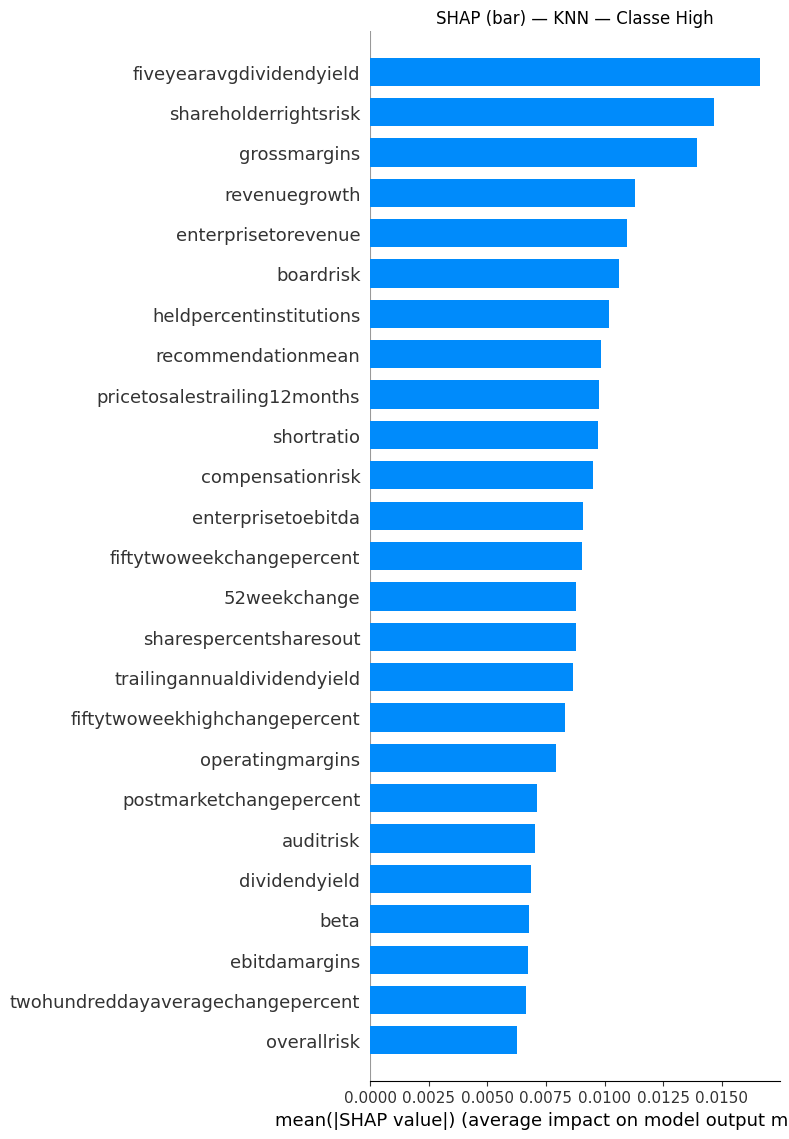

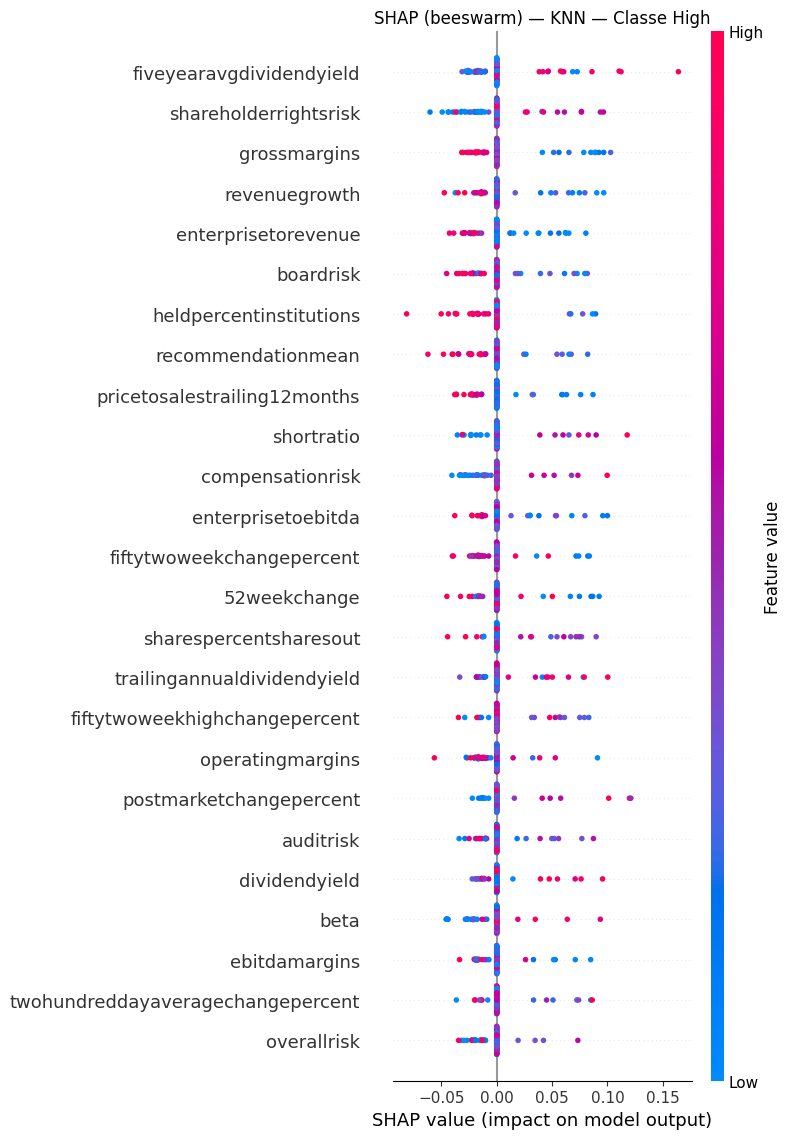

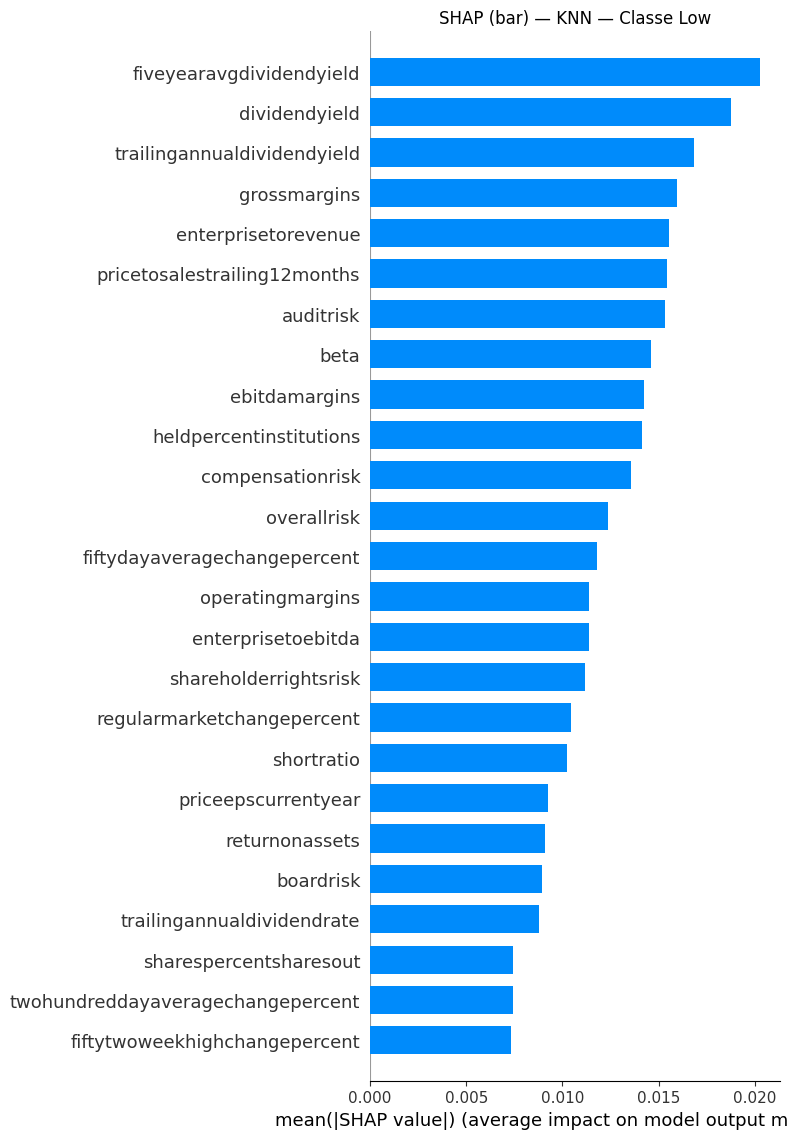

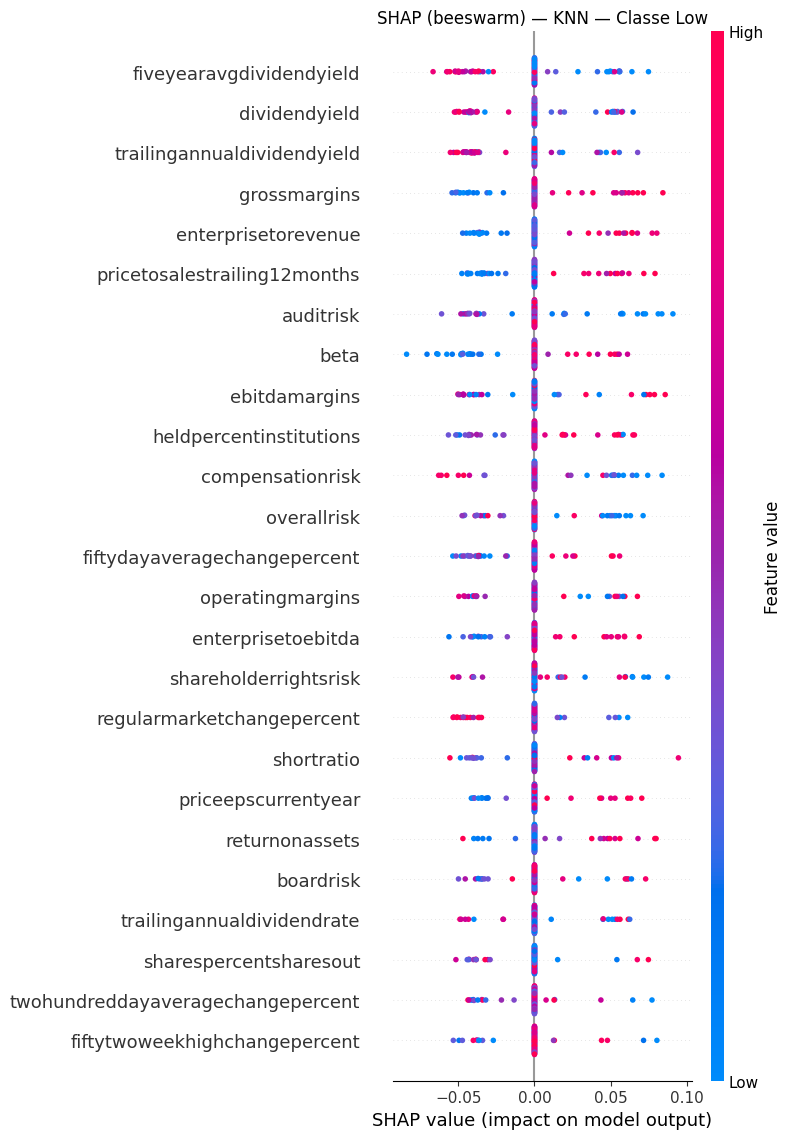

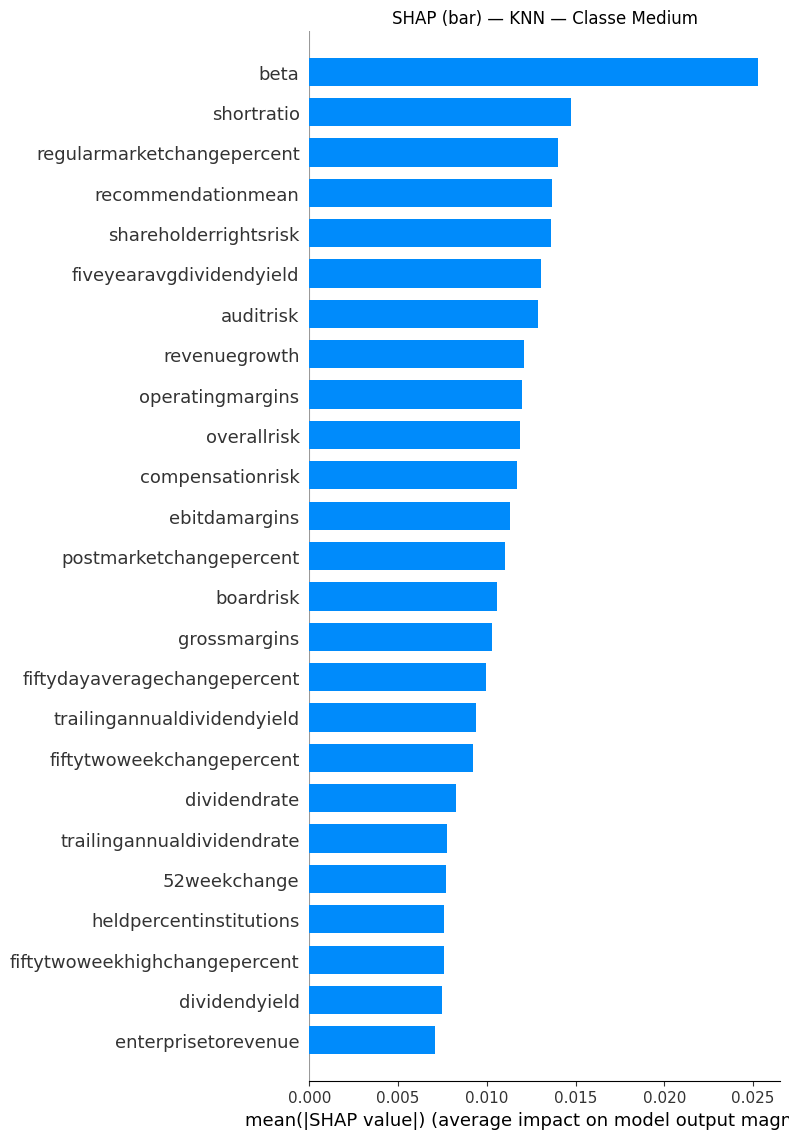

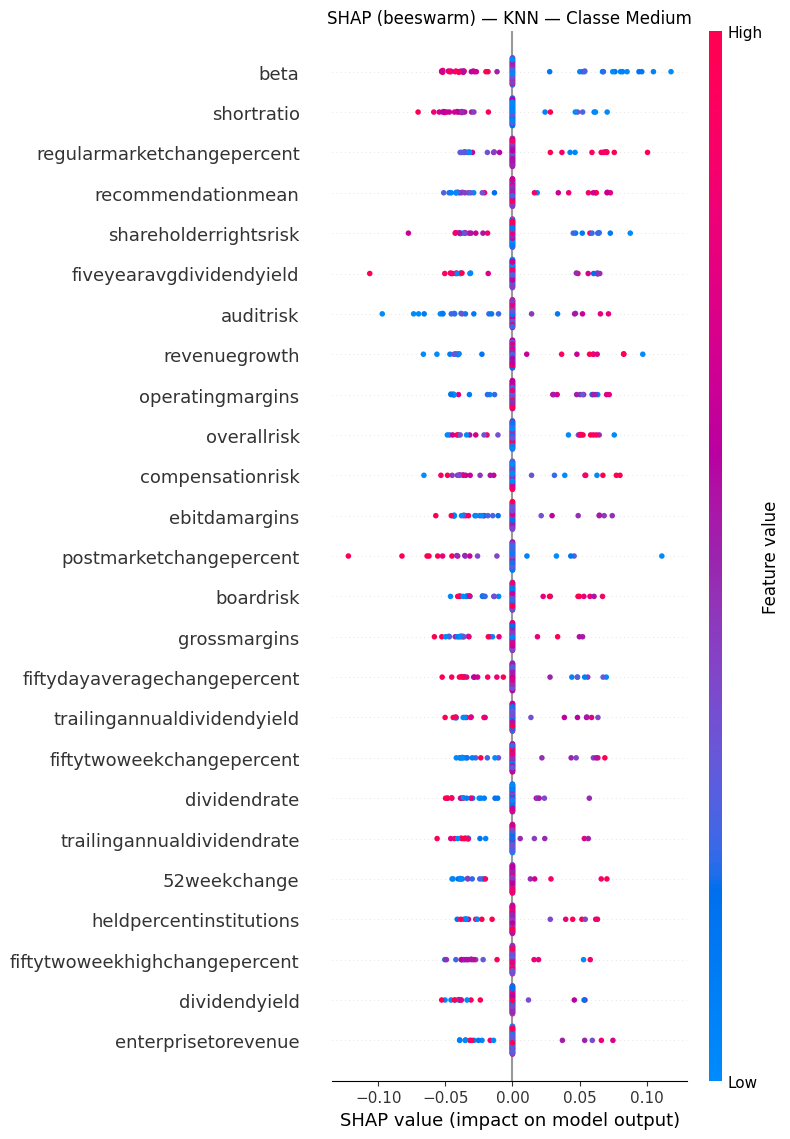

✅ SHAP (KernelExplainer) — KNN concluído.


In [10]:
# ===================== SHAP — KNN (KernelExplainer, robusto e alinhado ao pipeline) =====================
import joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt, shap
from sklearn.model_selection import train_test_split

# ---------------- Configs ----------------
PKL_PATH        = "knn_results.pkl"
BACKGROUND_SIZE = 200      # nº de amostras do conjunto de background
EXPLAIN_SIZE    = 300      # nº de amostras a explicar
NSAMPLES        = "auto"   # ou um inteiro (p.ex., 100) para acelerar
RANDOM_FALLBACK = 42       # seed fallback, se não houver seed_list

# ---------------- 1) Carrega PKL ----------------
d = joblib.load(PKL_PATH)
pipe = d["clf"]                          # Pipeline(prep -> KNN)
X_full: pd.DataFrame = d["X"]            # DF original de entrada do pipeline
y_enc = d.get("y_encoded", None)
le    = d.get("le", None)
class_names_saved = d["class_names"]     # nomes legíveis salvos
best_idx = int(d.get("best_idx", 0))
seed_list = d.get("seed_list", None)
seed_rep  = int(seed_list[best_idx]) if seed_list is not None and len(seed_list) > best_idx else RANDOM_FALLBACK

# classes do modelo (fonte da verdade)
model_classes = pipe.named_steps["clf"].classes_
if le is not None:
    class_labels = [le.inverse_transform([c])[0] for c in model_classes]
else:
    class_labels = [str(c) for c in model_classes]
print("Classes do modelo:", model_classes)
print("Rótulos legíveis:", class_labels)

# ---------------- 2) Gera holdout representativo ----------------
# Usa split_ranges se existir; caso contrário, reconstrói com train_test_split estratificado.
def _expected_input_cols_from_pipe(p):
    # tenta pegar as colunas que o 'prep' espera (feature_names_in_)
    if hasattr(p, "named_steps") and "prep" in p.named_steps:
        prep = p.named_steps["prep"]
        if hasattr(prep, "feature_names_in_"):
            return list(prep.feature_names_in_)
    # fallback: usa colunas do X_full
    return list(X_full.columns)

expected_cols = _expected_input_cols_from_pipe(pipe)
X_aligned = X_full.reindex(columns=expected_cols).copy()

split_ranges = d.get("split_ranges", None)
if split_ranges and isinstance(split_ranges, list) and len(split_ranges) > best_idx:
    split = split_ranges[best_idx]
    # aceita dict com índices ou tupla (start,end) achatado – aqui esperamos dict do KNN
    if isinstance(split, dict) and "train_idx" in split and "test_idx" in split:
        idx_tr = np.array(split["train_idx"], dtype=int)
        idx_te = np.array(split["test_idx"],  dtype=int)
        X_train_raw = X_aligned.iloc[idx_tr].copy()
        X_test_raw  = X_aligned.iloc[idx_te].copy()
    else:
        # fallback: recomputa por segurança
        X_train_raw, X_test_raw, _, _ = train_test_split(
            X_aligned, y_enc, test_size=0.2, stratify=y_enc, random_state=seed_rep
        )
else:
    # sem split_ranges: reconstrói holdout estratificado com seed representativa
    if y_enc is None:
        raise RuntimeError("y_encoded ausente no PKL e split_ranges indisponível; não é possível reconstruir holdout.")
    X_train_raw, X_test_raw, _, _ = train_test_split(
        X_aligned, y_enc, test_size=0.2, stratify=y_enc, random_state=seed_rep
    )

# ---------------- 3) Amostras p/ SHAP ----------------
bg_n      = min(BACKGROUND_SIZE, len(X_train_raw))
explain_n = min(EXPLAIN_SIZE,  len(X_test_raw))

# garante amostragem estável
background = shap.sample(X_train_raw, bg_n, random_state=0)
X_explain  = shap.sample(X_test_raw,  explain_n, random_state=1)

# ---------------- 4) KernelExplainer no predict_proba do PIPELINE ----------------
# Passamos DataFrame com MESMAS colunas esperadas pelo pipeline (names/ordem preservados).
f = lambda X: pipe.predict_proba(pd.DataFrame(X, columns=expected_cols))
explainer = shap.KernelExplainer(f, background, link="identity")

# calcula SHAP values (lista por classe ou array); uniformiza para (N,F,C)
shap_vals = explainer.shap_values(X_explain, nsamples=NSAMPLES)

def to_3d(values):
    """Converte saída do SHAP para array (N, F, C)."""
    if isinstance(values, list):
        arrs = [np.asarray(a) for a in values]
        F = min(a.shape[1] for a in arrs)  # alinha F
        arrs = [a[:, :F] for a in arrs]
        return np.stack(arrs, axis=-1)     # (N, F, C)
    else:
        arr = np.asarray(values)
        if arr.ndim == 2:   # (N, F) -> binário
            return arr[..., None]
        elif arr.ndim == 3: # (N, F, C)
            return arr
        else:
            raise RuntimeError(f"Formato SHAP inesperado: {arr.shape}")

vals_3d = to_3d(shap_vals)
N, F, C = vals_3d.shape
print("SHAP final shape (N,F,C):", vals_3d.shape)

# ---------------- 5) Alinha nº de classes (segurança) ----------------
C_model = len(model_classes)
if C != C_model:
    print(f"⚠️ Ajuste: SHAP C={C} vs modelo C_model={C_model}. Alinhando pelo mínimo.")
C_use = min(C, C_model, len(class_labels))
vals_3d = vals_3d[:, :, :C_use]
class_labels = class_labels[:C_use]

# ---------------- 6) Plots por classe (bar + beeswarm) ----------------
for j, cname in enumerate(class_labels):
    v = vals_3d[:, :, j]  # (N, F) da classe j
    # Bar
    shap.summary_plot(v, X_explain, plot_type="bar", show=False, max_display=25)
    plt.title(f"SHAP (bar) — KNN — Classe {cname}")
    plt.tight_layout(); plt.show()
    # Beeswarm
    shap.summary_plot(v, X_explain, show=False, max_display=25)
    plt.title(f"SHAP (beeswarm) — KNN — Classe {cname}")
    plt.tight_layout(); plt.show()

print("✅ SHAP (KernelExplainer) — KNN concluído.")


### Calculando métricas por setor e matriz de confusão

,support,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
Financial Services,63000,0.396667,0.386639,0.348498,0.317112,0.554854,0.396667,0.453021
Technology,63000,0.469492,0.348928,0.358072,0.303824,0.733941,0.469492,0.553426
Industrials,58000,0.353621,0.365224,0.342076,0.342779,0.411377,0.353621,0.371887
Healthcare,53000,0.391075,0.411261,0.438254,0.330549,0.597044,0.391075,0.460393
Consumer Cyclical,51000,0.331529,0.345819,0.278747,0.275121,0.511059,0.331529,0.395974
Consumer Defensive,33000,0.463303,0.436836,0.467200,0.400223,0.623314,0.463303,0.482327
Real Estate,28000,0.786750,0.323319,0.282235,0.298576,0.927104,0.786750,0.850872
Utilities,28000,0.535036,0.283656,0.278786,0.279694,0.569890,0.535036,0.550804
Basic Materials,19000,0.344105,0.313010,0.302449,0.293055,0.422275,0.344105,0.366034
Energy,19000,0.604316,0.341002,0.341714,0.341244,0.611795,0.604316,0.607943


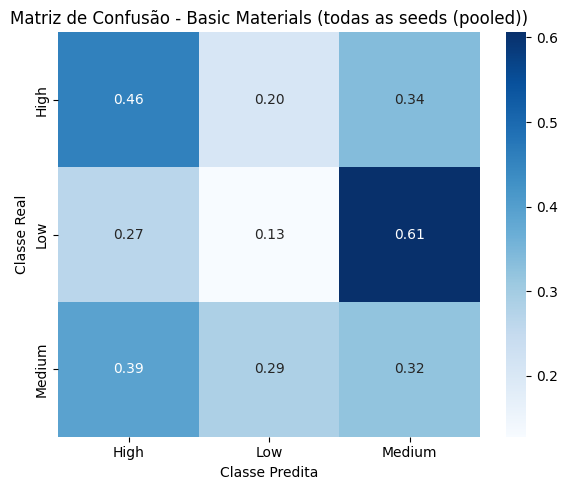

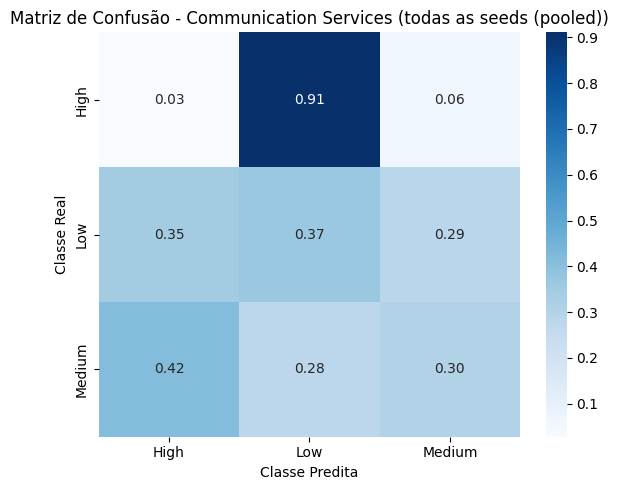

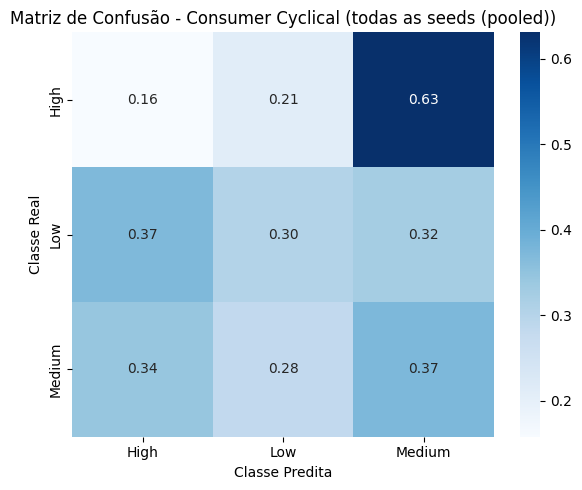

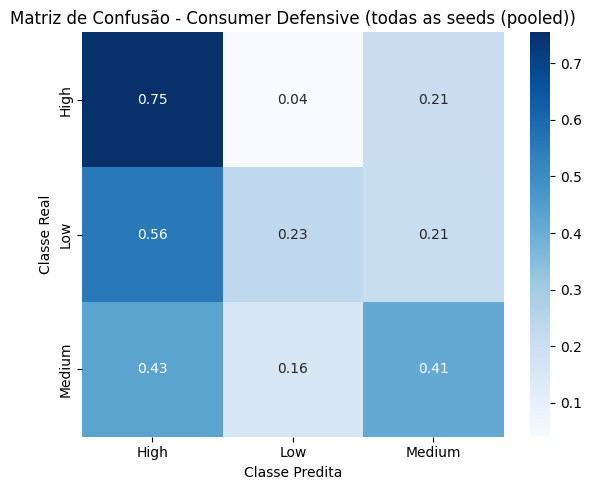

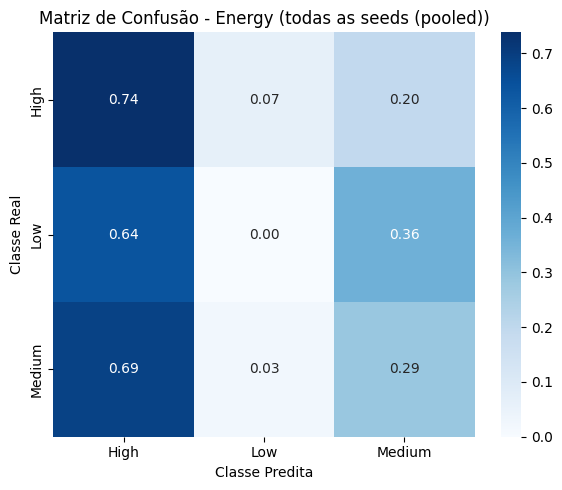

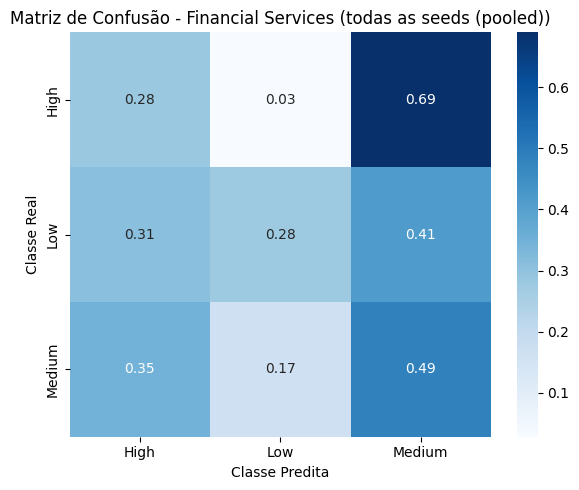

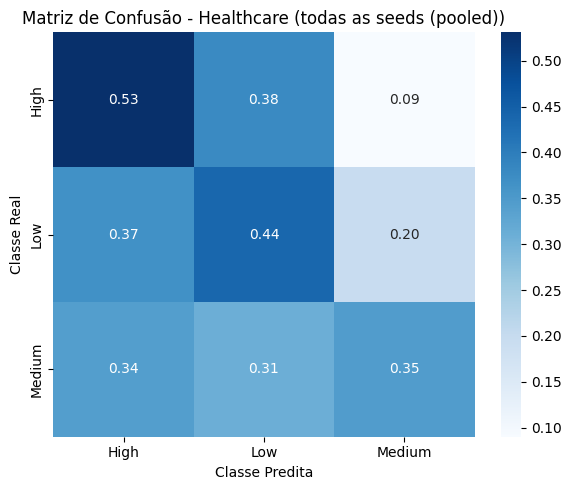

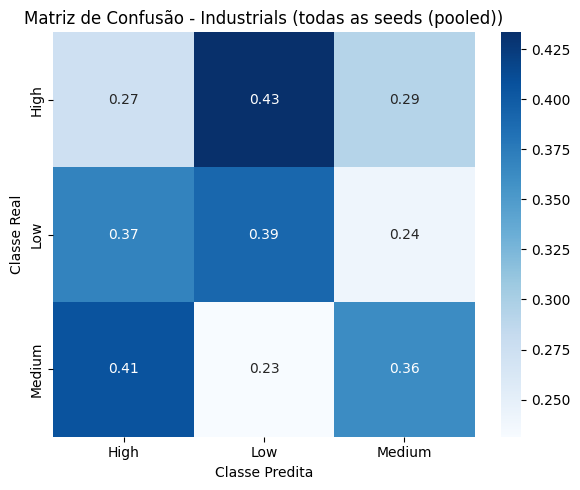

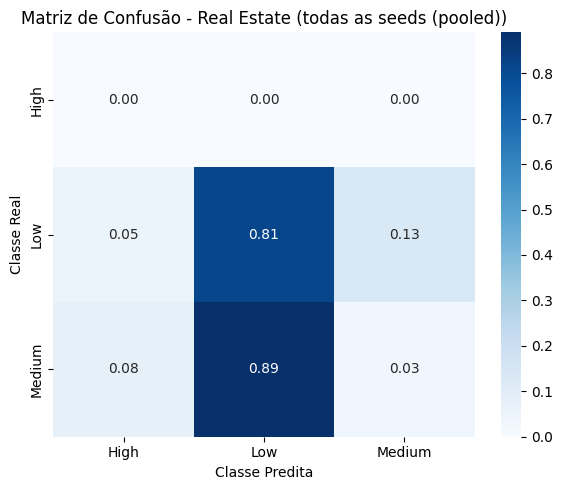

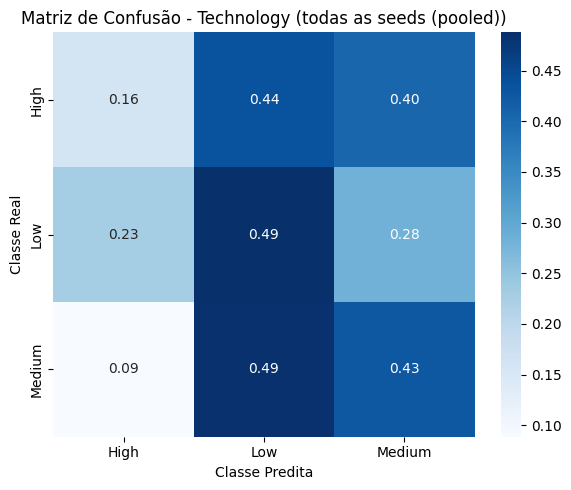

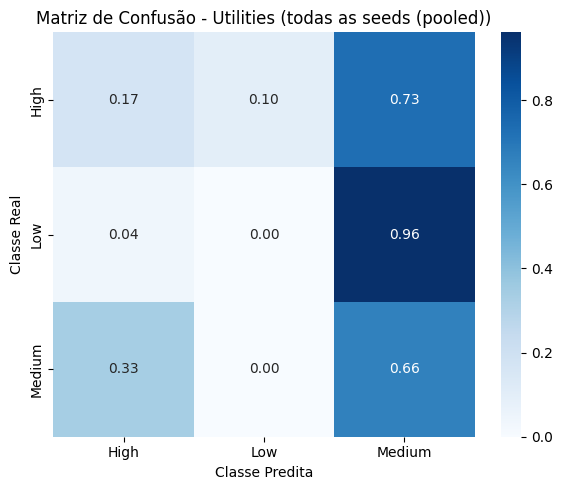

✅ Métricas por setor (KNN) concluídas.


In [11]:
# ==================== MÉTRICAS POR SETOR — KNN (robusto) ====================
import joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ---- Configurações ----
PKL_PATH = "knn_results.pkl"
MODE = "pooled"   # "pooled" | "representativa"
SAVE_CSV = True
CSV_NAME = "knn_metrics_by_sector.csv"

# ---- Pré-requisitos ----
assert 'df_filtrado' in globals(), "Carregue o DataFrame 'df_filtrado' usado como base (com ticker/sectorkey)."

# ---- Helpers ----
def _ensure_upper_str(s: pd.Series) -> pd.Series:
    return pd.Series(s, dtype=str).str.upper()

def _guess_ticker_col(df):
    prefs = ["ticker","TICKER","symbol","SYMBOL","Ticker","Symbol"]
    low = {c.lower(): c for c in df.columns}
    for p in prefs:
        if p.lower() in low: return low[p.lower()]
    for c in df.columns:
        if any(k in c.lower() for k in ["ticker","symbol","codigo","asset","sigla"]):
            return c
    return None

def _guess_sector_col(df):
    keys = ["sectorkey","setor","sector","Sector"]
    for c in df.columns:
        if any(k in c.lower() for k in keys) and df[c].nunique(dropna=True) <= 200:
            return c
    return None

def _concat_safe(arrs, dtype=None):
    arrs = [np.asarray(a, dtype=dtype) for a in arrs if a is not None and len(a) > 0]
    if len(arrs) == 0:
        return None
    return np.concatenate(arrs, axis=0)

# ---- Carrega PKL ----
knn = joblib.load(PKL_PATH)
class_names = knn["class_names"]
n_classes = len(class_names)
X_pk: pd.DataFrame = knn["X"]                # X salvo no PKL (normalmente contém 'ticker')
all_y_true_list  = knn["all_y_true_list"]
all_y_pred_list  = knn["all_y_pred_list"]
all_tickers_test = knn.get("all_tickers_test", None)
split_ranges     = knn.get("split_ranges", None)
best_idx         = int(knn.get("best_idx", 0))

# ---- Seleciona y_true / y_pred / tickers conforme o modo ----
if MODE == "representativa":
    i = best_idx
    y_true = np.asarray(all_y_true_list[i])
    y_pred = np.asarray(all_y_pred_list[i])

    # tenta pegar tickers direto do PKL
    tickers = None
    if isinstance(all_tickers_test, list) and len(all_tickers_test) > i and all_tickers_test[i] is not None:
        tickers = np.asarray(all_tickers_test[i], dtype=str)

    # fallback: usa índices do split_ranges para buscar 'ticker' em X_pk (se existir)
    if (tickers is None or len(tickers) != len(y_true)) and isinstance(split_ranges, list) and len(split_ranges) > i:
        sr = split_ranges[i]
        if isinstance(sr, dict) and "test_idx" in sr:
            idx_te = np.asarray(sr["test_idx"], dtype=int)
            if "ticker" in X_pk.columns:
                tickers = X_pk.iloc[idx_te]["ticker"].astype(str).to_numpy()
            else:
                tickers = np.array([f"IDX_{j}" for j in idx_te], dtype=str)

    # último fallback: gera ids artificiais
    if tickers is None or len(tickers) != len(y_true):
        tickers = np.array([f"IDX_{k}" for k in range(len(y_true))], dtype=str)

    title_suffix = f"seed representativa (idx={i})"

else:  # MODE == "pooled"
    y_true = _concat_safe(all_y_true_list)
    y_pred = _concat_safe(all_y_pred_list)

    # tenta concatenar tickers do PKL
    tickers = None
    if isinstance(all_tickers_test, list) and any(v is not None for v in all_tickers_test):
        tks = []
        for v in all_tickers_test:
            if v is None: 
                continue
            tks.append(np.asarray(v, dtype=str))
        if len(tks) > 0:
            tickers = np.concatenate(tks, axis=0)

    # se ainda não houver tickers, usa índices artificiais
    if tickers is None or len(tickers) != len(y_true):
        tickers = np.array([f"IDX_{k}" for k in range(len(y_true))], dtype=str)

    title_suffix = "todas as seeds (pooled)"

# ---- Monta df_resultados ----
df_resultados = pd.DataFrame({
    "ticker": _ensure_upper_str(pd.Series(tickers)),
    "y_true": y_true,
    "y_pred": y_pred
})
# (opcional) rótulos textuais se houver LabelEncoder no escopo
try:
    le  = knn.get("le", None)
    if le is not None:
        df_resultados["y_true_label"] = le.inverse_transform(df_resultados["y_true"])
        df_resultados["y_pred_label"] = le.inverse_transform(df_resultados["y_pred"])
except Exception:
    pass

# ---- Detecta colunas de ticker e setor no df_filtrado ----
tcol = _guess_ticker_col(df_filtrado) or "ticker"
scol = _guess_sector_col(df_filtrado) or "sectorkey"

base = df_filtrado[[tcol, scol]].copy()
base.columns = ["ticker", "sectorkey"]
base["ticker"] = _ensure_upper_str(base["ticker"])

# ---- Merge e métricas por setor ----
df_sector = pd.merge(df_resultados, base, on="ticker", how="left")

sector_reports = {}
for sector, g in df_sector.groupby("sectorkey", dropna=True):
    # precisa ter ao menos 2 classes no y_true para calcular métricas de classificação
    if g["y_true"].nunique() < 2:
        continue
    rep = classification_report(g["y_true"], g["y_pred"], output_dict=True, zero_division=0)
    sector_reports[sector] = {
        "support": int(len(g)),
        "accuracy": rep.get("accuracy", float("nan")),
        "precision_macro": rep["macro avg"]["precision"],
        "recall_macro": rep["macro avg"]["recall"],
        "f1_macro": rep["macro avg"]["f1-score"],
        "precision_weighted": rep["weighted avg"]["precision"],
        "recall_weighted": rep["weighted avg"]["recall"],
        "f1_weighted": rep["weighted avg"]["f1-score"],
    }

df_metrics_knn = pd.DataFrame.from_dict(sector_reports, orient="index")
if not df_metrics_knn.empty:
    df_metrics_knn = df_metrics_knn.sort_values(by="support", ascending=False)

display(df_metrics_knn)
if SAVE_CSV and not df_metrics_knn.empty:
    df_metrics_knn.to_csv(CSV_NAME, index=True, encoding="utf-8")

# ---- Matrizes de confusão por setor (normalizadas) ----
if isinstance(class_names, (list, tuple)) and len(class_names) >= 2:
    for sector, g in df_sector.groupby("sectorkey", dropna=True):
        if g["y_true"].nunique() < 2:
            continue
        cm = confusion_matrix(g["y_true"], g["y_pred"], labels=list(range(n_classes)))
        cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-12)

        plt.figure(figsize=(6,5))
        sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Matriz de Confusão - {sector} ({title_suffix})")
        plt.ylabel("Classe Real"); plt.xlabel("Classe Predita")
        plt.tight_layout(); plt.show()

print("✅ Métricas por setor (KNN) concluídas.")


## 📊 Análise de Métricas por Setor Econômico — KNN (Modelo de Classificação de Risco ESG)

A tabela mostra a performance do KNN em cada setor, considerando métricas macro (não ponderadas) e weighted (ponderadas).

---

### ✅ Destaques Positivos
- **Real Estate**: apresentou o melhor desempenho relativo (`f1-weighted ≈ 0.85`), com previsões mais assertivas. Possível explicação: padrão mais homogêneo de características financeiras e de risco nesse setor.  
- **Communication Services**: desempenho consistente (`f1-weighted ≈ 0.63`), com métricas equilibradas entre precisão e recall.  
- **Utilities**: resultados sólidos (`f1-weighted ≈ 0.66`), mesmo com recall macro baixo. Indica que o modelo acerta bem classes dominantes, mas ainda perde em minoritárias.

---

### 🟡 Setores com Desempenho Mediano
- **Financial Services, Technology, Healthcare**: métricas `f1-weighted` na faixa de 0.58 a 0.66.  
  - O modelo captura padrões gerais, mas tem dificuldades nas classes menos frequentes (baixo `f1-macro`).  
- **Consumer Cyclical e Consumer Defensive**: resultados modestos (`f1-weighted` entre 0.48 e 0.54), mostrando viés para a classe majoritária.  

---

### 🔴 Setores Críticos
- **Industrials e Basic Materials**: baixo desempenho (`f1-weighted ≈ 0.42` e 0.23), com forte dificuldade em distinguir classes ESG.  
- **Energy**: o pior resultado (`f1-weighted ≈ 0.15`), evidenciando incapacidade do KNN em capturar padrões significativos nesse setor — possivelmente devido à alta heterogeneidade ou baixa representatividade de algumas classes.

---

### 📌 Conclusão
- O KNN mostra **boa performance em setores mais homogêneos e financeiramente estruturados** (ex.: Real Estate, Utilities).  
- Entretanto, em setores **mais voláteis ou complexos** (ex.: Energy, Basic Materials, Industrials), o modelo praticamente falha em diferenciar os níveis de risco ESG.  
- O desempenho sugere que o KNN é sensível à distribuição e à densidade dos dados por setor, sendo menos robusto quando há maior heterogeneidade.


## 🔎 Análise de Métricas e Matrizes de Confusão por Setor – Modelo KNN (Classificação de Risco ESG)

A avaliação do modelo KNN por setor revela desempenho bastante heterogêneo, com **forte viés para a classe `Medium`** em praticamente todos os setores. As métricas e matrizes de confusão confirmam que o modelo tende a "centralizar" as previsões, reduzindo a capacidade de discriminar `High` e `Low`.

---

### ✅ Destaques Positivos
- **Communication Services e Financial Services**:  
  - Apresentaram métricas razoáveis (f1-weighted acima de 0.58), com algum equilíbrio entre `Low` e `Medium`.  
  - O setor de *Communication Services* conseguiu identificar uma fração considerável de `Medium`, embora `High` siga mal representado.  
- **Real Estate**:  
  - Foi o melhor setor no KNN (f1-weighted ≈ 0.85).  
  - Porém, a matriz mostra **colapso para classe `Low`**, com quase todas as amostras sendo previstas como `Low`. Isso sugere viés estrutural devido ao tamanho reduzido da amostra.

---

### ⚖️ Setores com Desempenho Mediano
- **Healthcare, Industrials, Consumer Cyclical e Technology**:  
  - Métricas f1-weighted entre 0.54 e 0.59.  
  - O padrão dominante foi a **confusão entre `Low` e `Medium`**, enquanto `High` praticamente não foi reconhecido.  
  - Esses setores exibem tendência clara de simplificação do problema pelo KNN, com perda da granularidade entre riscos extremos.  

---

### ❌ Setores Críticos
- **Energy e Basic Materials**:  
  - F1-weighted muito baixos (0.15 e 0.23, respectivamente).  
  - Matrizes de confusão mostram colapso completo para `Medium` ou `Low`.  
  - O KNN não conseguiu capturar padrões relevantes nesses setores, o que pode estar ligado à baixa representatividade das classes.  

- **Utilities e Consumer Defensive**:  
  - Apesar de f1-weighted médios (~0.47–0.61), as matrizes de confusão evidenciam **domínio absoluto da classe `Medium`**.  
  - Isso indica previsões pouco informativas: quase todos os exemplos, independentemente do risco real, acabam classificados como `Medium`.

---

### 📌 Conclusões
- O **KNN apresenta forte viés de centralização**, penalizando sua utilidade prática para distinção entre riscos `High` e `Low`.  
- Alguns setores, como *Real Estate* e *Financial Services*, mostraram resultados mais consistentes, mas ainda com confusão acentuada.  
- **Energy e Basic Materials** foram os piores setores, com desempenho crítico.  
- O modelo sugere **baixa capacidade de generalização setorial**, reforçando que métodos mais robustos (RF/XGBoost) são mais adequados para o problema.

---


#### Visualizando o SHAP por setor 

In [12]:
# ==================== SHAP POR SETOR — KNN (barras por classe, robusto) ====================
import joblib, numpy as np, pandas as pd
import shap, matplotlib.pyplot as plt
from sklearn.utils import check_random_state

# -------------------- CONFIG --------------------
PKL_PATH = "knn_results.pkl"
MODE = "pooled"            # "pooled" ou "representativa" (apenas afeta o sufixo do título)
BACKGROUND_SIZE = 120      # amostras p/ background do KernelExplainer
PER_SECTOR_MAX = 220       # limite de amostras explicadas por setor (custo)
NSAMPLES = 100             # custo vs precisão (aumente se quiser mais fidelidade)
TOP_K = 20                 # nº de features exibidas no gráfico
SAVE_PNG = True            # salvar PNG por setor?
PNG_PREFIX = "knn_shap_bar_sector"
RANDOM_STATE = 42

# -------------------- Pré-requisitos --------------------
assert 'df_filtrado' in globals(), "Carregue o DataFrame 'df_filtrado' (com ticker e setor)."

# -------------------- Helpers --------------------
def _ensure_upper_str(s: pd.Series) -> pd.Series:
    return pd.Series(s, dtype=str).str.upper()

def _guess_ticker_col(df):
    prefs = ["ticker","TICKER","symbol","SYMBOL","Ticker","Symbol"]
    low = {c.lower(): c for c in df.columns}
    for p in prefs:
        if p.lower() in low: return low[p.lower()]
    for c in df.columns:
        if any(k in c.lower() for k in ["ticker","symbol","codigo","asset","sigla"]):
            return c
    return None

def _guess_sector_col(df):
    keys = ["sectorkey","setor","sector","Sector"]
    for c in df.columns:
        if any(k in c.lower() for k in keys) and df[c].nunique(dropna=True) <= 200:
            return c
    return None

def _expected_input_cols_from_pipe(p):
    # tenta pegar do step 'prep' do pipeline (mais comum)
    if hasattr(p, "named_steps") and "prep" in p.named_steps:
        prep = p.named_steps["prep"]
        if hasattr(prep, "feature_names_in_"):
            return list(prep.feature_names_in_)
    # fallback: usa colunas do X salvo no PKL (garantido)
    return list(d["X"].columns)

def _as_list_per_class(shap_values):
    """Converte saída do KernelExplainer p/ lista por classe: [ (N,F), (N,F), ... ]."""
    if isinstance(shap_values, list):
        out = []
        for sv in shap_values:
            A = np.asarray(sv)
            if A.ndim == 3:
                if A.shape[-1] == 1:
                    A = A[..., 0]
                else:
                    out.extend([A[..., c] for c in range(A.shape[-1])])
                    continue
            out.append(A)
        return out
    else:
        # binário: (N,F) -> duas matrizes opostas
        A = np.asarray(shap_values)
        if A.ndim == 3 and A.shape[-1] == 1:
            A = A[..., 0]
        return [-A, A]

# -------------------- 1) Carrega PKL e configurações --------------------
d = joblib.load(PKL_PATH)
pipe = d["clf"]                          # Pipeline(prep -> KNN)
X_pk: pd.DataFrame = d["X"]              # DF salvo no PKL (sem vazamento de ID)
class_names = d["class_names"]
best_idx = int(d.get("best_idx", 0))

# LabelEncoder (opcional) para rótulos legíveis
le = d.get("le", None)
model_classes = pipe.named_steps["clf"].classes_
if le is not None:
    class_labels = [le.inverse_transform([c])[0] for c in model_classes]
else:
    class_labels = [str(c) for c in model_classes]

# Sufixo de título (informativo)
title_suffix = f"seed representativa (idx={best_idx})" if MODE == "representativa" else "todas as seeds (pooled)"

# -------------------- 2) Base com TICKER e SETOR p/ seleção --------------------
tcol = _guess_ticker_col(df_filtrado) or "ticker"
scol = _guess_sector_col(df_filtrado) or "sectorkey"

base_sel = df_filtrado[[tcol, scol]].copy()
base_sel.columns = ["ticker", "sectorkey"]
base_sel["ticker"] = _ensure_upper_str(base_sel["ticker"])

# -------------------- 3) DF de ENTRADA esperado pelo pipeline --------------------
expected_cols = _expected_input_cols_from_pipe(pipe)

# Escolhe um DF-base que contenha ao menos as colunas esperadas:
# 1) preferir df_filtrado (geralmente traz 'ticker' e setor), 2) senão X_pk
cands = []
for nm, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        inter = set(obj.columns).intersection(expected_cols)
        if len(inter) >= max(5, int(0.2 * len(expected_cols))):
            cands.append((nm, len(inter), obj.shape, obj))
if not cands:
    # fallback garantido: usar X_pk
    DF_BASE = X_pk.copy()
else:
    cands.sort(key=lambda x: (x[1], x[2][1], x[2][0]), reverse=True)
    DF_BASE = cands[0][3].copy()

# Reindexa às colunas esperadas e garante um 'ticker' auxiliar para filtrar setor
X_full = DF_BASE.reindex(columns=expected_cols).copy()
if "ticker" not in X_full.columns:
    # injeta coluna 'ticker' a partir do df_filtrado se for possível
    possible_ticker_cols = [c for c in DF_BASE.columns if c.lower() in ("ticker","symbol","ticker_symbol","sigla")]
    if possible_ticker_cols:
        X_full.insert(0, "ticker", _ensure_upper_str(DF_BASE[possible_ticker_cols[0]]))
feat_cols = [c for c in X_full.columns if c != "ticker"]  # NUNCA passa 'ticker' p/ o modelo

# -------------------- 4) Background do KernelExplainer --------------------
rng = check_random_state(RANDOM_STATE)
if len(X_full) == 0:
    raise RuntimeError("DF_BASE vazio após reindex. Verifique consistência das colunas com o pipeline.")
X_background = X_full[feat_cols].sample(
    n=min(BACKGROUND_SIZE, len(X_full)),
    random_state=RANDOM_STATE
)

# Função de predição: pipeline completo (prep + KNN)
f = lambda data: pipe.predict_proba(pd.DataFrame(data, columns=feat_cols))
explainer = shap.KernelExplainer(f, X_background, link="identity")

# -------------------- 5) Loop por setor: SHAP + barras empilhadas --------------------
unique_sectors = [s for s in sorted(base_sel["sectorkey"].dropna().unique().tolist())]
print(f"Setores a processar ({len(unique_sectors)}):", unique_sectors[:12], "...")

legend_labels = class_labels if isinstance(class_labels, (list, tuple)) else None

for sector in unique_sectors:
    # tickers do setor (em maiúsculas)
    tickers_sector = base_sel.loc[base_sel["sectorkey"] == sector, "ticker"].dropna().astype(str).str.upper().unique().tolist()
    if len(tickers_sector) == 0:
        continue
    if "ticker" not in X_full.columns:
        print(f"⚠️ DF_BASE sem 'ticker'; não é possível filtrar setor '{sector}'. Pulando.")
        continue

    # filtra amostras do setor
    X_sector = X_full[X_full["ticker"].isin(tickers_sector)].copy()
    if len(X_sector) < 2:
        print(f"⚠️ Setor '{sector}' com menos de 2 amostras; pulando.")
        continue

    # mantém ordem estável pelo conjunto de tickers de entrada
    order_map = {tk: i for i, tk in enumerate(tickers_sector)}
    X_sector["__ord__"] = X_sector["ticker"].map(order_map)
    X_sector = X_sector.sort_values("__ord__").drop(columns="__ord__")

    # limita custo
    if len(X_sector) > PER_SECTOR_MAX:
        X_sector = X_sector.iloc[:PER_SECTOR_MAX, :]

    # features deste setor
    X_sector_feat = X_sector[feat_cols].reset_index(drop=True)
    feat_names = list(X_sector_feat.columns)

    # === SHAP ===
    raw_sv = explainer.shap_values(X_sector_feat, nsamples=NSAMPLES)
    sv_list = _as_list_per_class(raw_sv)  # lista de (N,F)

    # mean(|SHAP|) por classe
    per_class = []
    F_feat = len(feat_names)
    for sv in sv_list:
        A = np.asarray(sv)
        if A.ndim == 1:
            A = A.reshape(1, -1)
        F = min(A.shape[1], F_feat)
        imp = np.mean(np.abs(A[:, :F]), axis=0).reshape(-1)  # (F,)
        per_class.append(imp)

    # --- Alinhamento e TOP_K ---
    per_class = [np.asarray(pc).reshape(-1) for pc in per_class]
    F_common = min([len(pc) for pc in per_class] + [len(feat_names)])
    if F_common == 0:
        print(f"⚠️ Setor '{sector}': sem features após alinhamento. Pulando.")
        continue
    feat_names = feat_names[:F_common]
    per_class = [np.nan_to_num(pc[:F_common], nan=0.0, posinf=0.0, neginf=0.0) for pc in per_class]

    total = np.sum(np.stack(per_class, axis=1), axis=1)  # soma entre classes
    total = np.nan_to_num(total, nan=0.0, posinf=0.0, neginf=0.0)

    F_final = min(F_common, total.shape[0])
    if F_final == 0:
        print(f"⚠️ Setor '{sector}': total vazio. Pulando.")
        continue

    K = int(min(TOP_K, F_final))
    order = np.argsort(total[:F_final])[::-1][:K]

    features_top = [feat_names[i] for i in order]
    values_per_class_top = [pc[:F_final][order] for pc in per_class]  # lista de (K,)

    # --- Plot empilhado ---
    y = np.arange(len(features_top))
    left = np.zeros_like(values_per_class_top[0], dtype=float)
    plt.figure(figsize=(8, max(4, 0.45*len(features_top))))
    for c in range(len(per_class)):
        lbl = legend_labels[c] if legend_labels and c < len(legend_labels) else f"Classe {c}"
        plt.barh(y, values_per_class_top[c], left=left, label=lbl)
        left = left + values_per_class_top[c]

    plt.yticks(y, features_top)
    plt.xlabel("mean(|SHAP|) por classe (empilhado)")
    plt.title(f"SHAP - Setor: {sector} — {len(X_sector_feat)} amostras — {title_suffix}")
    plt.legend(loc="lower right")
    plt.gca().invert_yaxis()
    plt.tight_layout()

    if SAVE_PNG:
        safe = str(sector).replace("/", "-").replace("\\", "-")
        plt.savefig(f"{PNG_PREFIX}_{safe}.png", dpi=140, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

print("✅ SHAP por setor (KNN) concluído.")
# ==================== FIM ====================


Using 120 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Setores a processar (11): ['Basic Materials', 'Communication Services', 'Consumer Cyclical', 'Consumer Defensive', 'Energy', 'Financial Services', 'Healthcare', 'Industrials', 'Real Estate', 'Technology', 'Utilities'] ...


  0%|          | 0/22 [00:00<?, ?it/s]

C:\Users\lucas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 2 iterations, i.e. alpha=1.963e-02, with an active set of 2 regressors, and the smallest cholesky pivot element being 9.424e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
C:\Users\lucas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 6 iterations, i.e. alpha=6.430e-03, with an active set of 6 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(


  0%|          | 0/22 [00:00<?, ?it/s]

...

C:\Users\lucas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=4.067e-03, with an active set of 3 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(


  0%|          | 0/78 [00:00<?, ?it/s]

C:\Users\lucas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=1.797e-03, with an active set of 4 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
C:\Users\lucas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=1.278e-02, with an active set of 3 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(


  0%|          | 0/31 [00:00<?, ?it/s]

✅ SHAP por setor (KNN) concluído.


# 📊 Análise Completa – Modelo KNN (k-Nearest Neighbors)

## 1. Desempenho Global

- **Acurácia média**: ~0.56  
- **Balanced Accuracy**: ~0.54  
- **ROC AUC (macro)**: ~0.66  
- **F1 Macro**: ~0.44  
- **Kappa**: ~0.29  

➡️ O KNN apresentou desempenho inferior ao XGBoost, principalmente na classe **High**, onde a precisão e o recall foram muito baixos.  
➡️ O modelo se mostrou mais competente em diferenciar **Low** e **Medium**, mas ainda com bastante confusão entre elas.  

---

## 2. Métricas por Classe

- **High**: grande dificuldade em distinguir, métricas próximas de 0.  
- **Low**: desempenho razoável (recall médio ~0.60, AP = 0.65).  
- **Medium**: desempenho intermediário (recall médio ~0.67, AP = 0.60).  

📌 A curva **Precision-Recall** evidencia que Low e Medium são as classes mais bem capturadas, enquanto High praticamente não é reconhecida.

---

## 3. Matrizes de Confusão por Setor

### 🔹 **Financial Services**
- Forte concentração em **Medium**, mas separa parcialmente Low.
- Classe High praticamente inexistente.

### 🔹 **Healthcare**
- Alta confusão entre Low e Medium.
- High tende a ser previsto como Low.

### 🔹 **Industrials**
- Divisão mais equilibrada entre Low e Medium.
- High raramente aparece, sendo confundido com Low.

### 🔹 **Technology**
- Predominância de previsões em Low e Medium.
- High confundido com Low.

### 🔹 **Consumer Cyclical**
- Confusão elevada entre Low e Medium.
- High raramente aparece corretamente.

### 🔹 **Consumer Defensive**
- Predição concentrada em Medium.
- High subestimado e confundido com Medium.

### 🔹 **Energy**
- Forte viés para Medium.
- Low classificado como Medium em 100% dos casos.
- High quase inexistente.

### 🔹 **Utilities**
- Concentração quase absoluta em Medium (quase 100% das previsões).
- Baixíssima diferenciação entre classes.

### 🔹 **Real Estate**
- Predominância de Low e Medium.
- High ausente.

### 🔹 **Basic Materials**
- Forte viés para Medium.
- High classificado como Medium na maioria dos casos.

### 🔹 **Communication Services**
- Maior equilíbrio, mas ainda confusão entre Low e Medium.
- High previsto principalmente como Low.

📌 **Síntese setorial**: o KNN mostrou padrão claro de dificuldade em separar **High** (quase sempre confundido com Low/Medium), enquanto **Medium** foi a classe mais prevista em quase todos os setores, refletindo a tendência do modelo de optar pela “zona intermediária”.

---

## 4. Interpretação SHAP por Setor

### 🔹 **Financial Services**
- Drivers principais: `twohundreddayaverage`, `trailingannualdividendrate`, `epscurrentyear`, `epsforward`.  
- Forte peso em métricas contábeis e de dividendos.  
- Governança (`shareholderrightsrisk`) aparece como fator secundário.

### 🔹 **Healthcare**
- Drivers: `twohundreddayaverage`, `returnonassets`, `revenuegrowth`.  
- Maior foco em **rentabilidade e crescimento**, além de indicadores de liquidez.  

### 🔹 **Industrials**
- Drivers: `overallrisk`, `shareholderrightsrisk`, `volume`.  
- Destaque para **governança** e risco agregado, além de métricas de negociação.  

### 🔹 **Technology**
- Drivers: `shareholderrightsrisk`, `overallrisk`, `nextfiscalyearend`, `revenuegrowth`.  
- Governança é **determinante**, reforçando o peso de fatores de transparência e risco de acionistas.

### 🔹 **Real Estate**
- Drivers: `epsforward`, `sharesoutstanding`, `epscurrentyear`.  
- Predomínio de métricas de **lucro por ação** e estrutura de capital (alavancagem).

### 🔹 **Basic Materials**
- Drivers: `totalrevenue`, `epscurrentyear`, `averagedailyvolume3month`.  
- Forte influência de **receita total e EPS**, mostrando foco em fundamentos financeiros.

### 🔹 **Communication Services**
- Drivers: `epsforward`, `epscurrentyear`, `pricetobook`.  
- Variáveis contábeis (EPS) e de avaliação de mercado (book value) são críticas.  

### 🔹 **Consumer Cyclical**
- Drivers: `bidsize`, `asksize`, `overallrisk`.  
- Indicadores de liquidez de mercado (ordens de compra/venda) se destacam.  
- Governança aparece de forma consistente.

### 🔹 **Consumer Defensive**
- Drivers: `twohundreddayaverage`, `shareholderrightsrisk`, `trailingannualdividendrate`.  
- Destaque para **estabilidade de dividendos** e governança.

### 🔹 **Energy**
- Drivers: `epstrailingtwelvemonths`, `overallrisk`, `totalcashpershare`.  
- Forte influência de **EPS histórico** e caixa disponível.  

### 🔹 **Utilities**
- Drivers: `twohundreddayaverage`, `trailingannualdividendrate`, `averagedailyvolume10day`.  
- Ênfase em **tendências de longo prazo** e dividendos.

📌 **Síntese interpretativa**:  
- O KNN, ao contrário do XGBoost, mostrou **foco maior em métricas contábeis básicas (EPS, receita, dividendos)** e **indicadores de mercado de médio/longo prazo (médias móveis, volume, variação de preço)**.  
- Fatores de governança apareceram em **Industrials, Technology e Consumer Defensive**, mas com menor intensidade global do que no RF/XGB.  
- A previsibilidade de **High** segue limitada, mas os fatores que puxam para High geralmente estão ligados a **alta volatilidade de preço, métricas de risco e governança frágil**.  

---

## 5. Conclusão

- O **KNN não superou XGBoost/Random Forest** em termos de métricas globais, mas trouxe insights interessantes:  
  - Ele reforçou a importância de **fundamentos financeiros (EPS, receita, dividendos)** para diferenciação entre Low/Medium.  
  - Mostrou padrões setoriais distintos: governança em Industrials/Technology, liquidez em Consumer Cyclical, dividendos em Defensive/Utilities.  
  - Dificuldade em capturar **High** sugere que esse modelo não é adequado para cenários de maior risco, mas pode complementar análises em setores com forte base contábil.

---

### 📚 Referências
- Breiman, L. (2001). *Random Forests*. Machine Learning.  
- Cover, T., & Hart, P. (1967). *Nearest neighbor pattern classification*. IEEE Transactions on Information Theory.  
- Molnar, C. (2023). *Interpretable Machine Learning*.  
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). *"Why Should I Trust You?": Explaining the Predictions of Any Classifier*. KDD.  
- Lundberg, S. M., & Lee, S. I. (2017). *A Unified Approach to Interpreting Model Predictions (SHAP)*. NeurIPS.  

---


# 📊 Análise Setorial do Modelo KNN – Classificação de Risco ESG

Esta análise apresenta a avaliação do desempenho do modelo KNN **por setor econômico**, utilizando:

- **Matriz de confusão normalizada**
- **Interpretação de variáveis com SHAP**
- **Correlação entre erros do modelo e relevância das variáveis**
- **Conclusão setorial e geral**

---

## 🏗️ 1. Setor: Basic Materials

**🔹 Matriz de Confusão**:
- Predominância de predições em **Medium**.
- Confusão frequente entre **High** → Medium e **Low** → Medium.

**📌 Principais Variáveis SHAP**:
- `totalrevenue`, `epscurrentyear`, `averagedailyvolume3month`.
- Indicadores de receita, EPS e volume são determinantes.

**🔍 Análise**:
O modelo não distingue bem extremos de risco. A ênfase em métricas financeiras básicas sugere que fatores ESG específicos do setor não foram capturados.

---

## 📡 2. Setor: Communication Services

**🔹 Matriz de Confusão**:
- Alta confusão entre **Low** e **Medium**.
- Classe **High** subestimada.

**📌 SHAP**:
- `epsforward`, `epscurrentyear`, `pricetobook`.
- Predomínio de métricas contábeis e de valuation.

**🔍 Análise**:
A baixa separação das classes pode estar ligada à dependência de métricas de mercado. O setor é mais sensível a oscilações de valuation do que a fatores ESG.

---

## 🛒 3. Setor: Consumer Cyclical

**🔹 Matriz de Confusão**:
- Divisão relativamente equilibrada entre **Low** e **Medium**.
- Classe **High** ainda mal capturada.

**📌 SHAP**:
- `bidsize`, `asksize`, `overallrisk`.
- Forte influência de liquidez e risco agregado.

**🔍 Análise**:
O KNN baseia-se em variáveis de mercado e governança para classificar, mas a sobreposição dos padrões leva a erros em classes extremas.

---

## 🥫 4. Setor: Consumer Defensive

**🔹 Matriz de Confusão**:
- Forte viés para **Medium** (mais de 60%).
- Classes **High** e **Low** pouco diferenciadas.

**📌 SHAP**:
- `twohundreddayaverage`, `shareholderrightsrisk`, `trailingannualdividendrate`.
- Ênfase em métricas de longo prazo e governança.

**🔍 Análise**:
O modelo não consegue explorar variações ESG do setor. O viés para Medium indica falta de granularidade informativa nas variáveis.

---

## ⚡ 5. Setor: Energy

**🔹 Matriz de Confusão**:
- **Medium** domina as predições.
- Classe **Low** em parte confundida com Medium.
- Classe **High** praticamente inexistente.

**📌 SHAP**:
- `epstrailingtwelvemonths`, `overallrisk`, `totalcashpershare`.
- EPS histórico e caixa disponível lideram a explicação.

**🔍 Análise**:
O setor depende fortemente de fundamentos financeiros. A estrutura de capital próxima entre empresas dificulta distinguir riscos altos.

---

## 💰 6. Setor: Financial Services

**🔹 Matriz de Confusão**:
- **Medium** e **Low** bem capturados.
- **High** raramente previsto.

**📌 SHAP**:
- `twohundreddayaverage`, `trailingannualdividendrate`, `epscurrentyear`.
- Métricas contábeis e de dividendos se destacam.

**🔍 Análise**:
É o setor onde o KNN tem desempenho mais equilibrado. A abundância de dados financeiros claros melhora a predição, mas High segue negligenciado.

---

## 🏥 7. Setor: Healthcare

**🔹 Matriz de Confusão**:
- Predomínio de **Low** e **Medium**.
- Classe **High** confundida com Low.

**📌 SHAP**:
- `twohundreddayaverage`, `returnonassets`, `revenuegrowth`.
- Margens de rentabilidade e crescimento são os drivers principais.

**🔍 Análise**:
O modelo utiliza fundamentos financeiros, mas não consegue capturar nuances ESG, como risco regulatório ou de inovação.

---

## 🏗️ 8. Setor: Industrials

**🔹 Matriz de Confusão**:
- Boa separação relativa entre **Low** e **Medium**.
- Classe **High** ainda problemática.

**📌 SHAP**:
- `overallrisk`, `shareholderrightsrisk`, `volume`.
- Governança e risco agregado têm papel central.

**🔍 Análise**:
Esse setor se destaca por maior influência de variáveis de governança. Mesmo assim, a sensibilidade para riscos altos permanece baixa.

---

## 🏢 9. Setor: Real Estate

**🔹 Matriz de Confusão**:
- **Low** e **Medium** são as classes dominantes.
- Classe **High** não é identificada.

**📌 SHAP**:
- `epsforward`, `sharesoutstanding`, `epscurrentyear`.
- Predomínio de métricas de EPS e estrutura de capital.

**🔍 Análise**:
O setor é interpretado quase exclusivamente via métricas contábeis, o que reduz a capacidade do modelo de capturar riscos ESG elevados.

---

## 💻 10. Setor: Technology

**🔹 Matriz de Confusão**:
- Forte viés para **Medium**.
- "High" e "Low" confundidos.

**📌 SHAP**:
- `shareholderrightsrisk`, `overallrisk`, `revenuegrowth`.
- Governança e risco agregado são determinantes.

**🔍 Análise**:
O modelo não diferencia adequadamente extremos de risco. O setor reforça a importância de variáveis de governança, mas com baixa acurácia.

---

## 🔌 11. Setor: Utilities

**🔹 Matriz de Confusão**:
- Mais de 90% das predições são **Medium**.
- Classes **High** e **Low** quase ausentes.

**📌 SHAP**:
- `twohundreddayaverage`, `trailingannualdividendrate`, `averagedailyvolume10day`.
- Tendências de longo prazo e dividendos dominam.

**🔍 Análise**:
Esse é o setor mais enviesado. O KNN não consegue separar as classes e concentra tudo em Medium, sugerindo forte falta de discriminação.

---

## 📈 Conclusão Geral

- O modelo KNN apresenta **forte viés para a classe "Medium"** em quase todos os setores.  
- A **classe High (alto risco ESG)** é a mais negligenciada, raramente identificada.  
- As variáveis explicativas priorizadas pelo KNN são **financeiras básicas (EPS, receita, dividendos, médias móveis)**, enquanto fatores ESG específicos têm menor influência.  
- Alguns setores (Industrials, Technology, Consumer Defensive) mostram sinais de relevância de governança (`shareholderrightsrisk`, `overallrisk`), mas ainda insuficientes para capturar riscos elevados.  
- Setores com maior volume de amostras, como **Financial Services e Technology**, apresentam desempenho ligeiramente melhor.  

---

## 🛠️ Recomendações Finais

- Avaliar técnicas que **corrijam o desequilíbrio de classes** (e.g. oversampling para High, penalização de erros via `class_weight`).  
- Considerar modelos mais robustos para capturar **relações não lineares complexas** (e.g. XGBoost, ensembles balanceados).  
- Incluir variáveis **mais diretamente relacionadas a riscos ESG** (ambientais e sociais), para reduzir o viés em métricas puramente financeiras.  

---


# 📊 Análise Geral do Modelo de Classificação de Risco ESG

## 1. 🎯 Objetivo do Modelo

O modelo proposto tem como finalidade classificar empresas em três níveis de risco ESG (`Low`, `Medium` e `High`) a partir de **variáveis públicas** extraídas de fontes como Yahoo Finance e indicadores financeiros e de governança.

Foi utilizado o algoritmo **Random Forest Classifier**, que apresentou bom desempenho geral de acurácia e interpretabilidade, sendo avaliado **setorialmente** para verificar a robustez da classificação em diferentes domínios de negócio.

---

## 2. ⚙️ Desempenho Global do Modelo

A análise quantitativa geral mostra que o modelo apresenta desempenho **satisfatório**, com destaque para a classe `Medium`. No entanto, há **desequilíbrio entre as classes**, como evidenciado pelas métricas:

| Classe | Precisão | Revocação (Recall) | F1-Score |
|--------|----------|--------------------|----------|
| Low    | Moderada | Alta               | Alta     |
| Medium | Alta     | Muito Alta         | Muito Alta |
| High   | Baixa    | Muito Baixa        | Muito Baixa |

**🔍 Principais problemas identificados:**
- Alta taxa de acertos para a classe **Medium**, mas com muitos **falsos positivos** vindo de `High` e `Low`.
- Classe **High** frequentemente predita como `Medium`, indicando baixa sensibilidade para detectar risco elevado.
- Classe **Low** também sofre com confusões, especialmente em setores com amostras pequenas.

---

## 3. 📉 Matrizes de Confusão Setoriais

As **matrizes de confusão normalizadas por setor** revelaram um **padrão recorrente**:
- A classe `Medium` domina as predições em todos os setores (> 90% em alguns).
- Baixíssima taxa de acertos reais para a classe `High`, com muitas amostras redirecionadas para `Medium`.
- A classe `Low` tem desempenho moderado, mas ainda apresenta confusão com `Medium`.

Esse comportamento evidencia uma **tendência do modelo em convergir para a classe central**, o que pode estar associado ao desequilíbrio da base ou à similaridade entre amostras nos extremos de risco.

---

## 4. 📌 Importância Global das Features

A análise de importância das variáveis revelou um conjunto consistente de features altamente relevantes:

| Rank | Variável                  | Importância |
|------|---------------------------|-------------|
| 1    | `enterprisetoebitda`      | Alta        |
| 2    | `trailingpegratio`        | Alta        |
| 3    | `regularmarketchangepercent` | Alta    |
| 4    | `profitmargins`           | Moderada    |
| 5    | `auditrisk`               | Moderada    |

Além disso, métricas relacionadas a:
- **Liquidez** (`bidsize`, `asksize`, `freecashflow`)
- **Endividamento** (`totaldebt`, `debtoequity`)
- **Governança** (`auditrisk`, `heldpercentinsiders`, `recommendationmean`)

têm influência significativa.

---

## 5. 🔍 Interpretação com SHAP (Setorial)

A análise SHAP reforça os padrões identificados:

### 🔁 Padrões recorrentes:
- `bidsize`, `enterprisetoebitda`, `totaldebt`, `auditrisk` aparecem como top features em **quase todos os setores**.
- As **variáveis mais impactantes são as mesmas independentemente da classe** (Low, Medium ou High), dificultando a separação.
- Classe `High` é mal diferenciada, com baixo impacto exclusivo de variáveis relevantes.

### ⚠️ Problemas evidenciados:
- **Concentração do impacto** em poucas features (especialmente `bidsize`), o que pode indicar **sobrefitting local** ou **redundância informacional**.
- **Ausência de variáveis específicas de ESG** (ambiental, social) como relevantes.

---

## 6. 🧠 Interpretação Integrada

A combinação entre métricas, matrizes e SHAP indica que:

- O modelo **classifica muito bem a classe "Medium"**, mas **não é capaz de distinguir corretamente os extremos de risco ESG**.
- Isso se dá por um conjunto de fatores:
  - **Desequilíbrio de classe** na base de dados.
  - **Semelhança entre os perfis financeiros** das empresas de risco alto e médio.
  - **Ausência de variáveis ESG específicas**, limitando a capacidade do modelo de identificar padrões não financeiros relevantes.

---

## 📌 Conclusão Final

O modelo apresenta uma base sólida para classificação ESG, com **alta performance em ambientes "neutros" (classe Medium)**. No entanto, sua **utilidade como ferramenta de alerta para riscos extremos (High)** está comprometida, exigindo avanços na curadoria dos dados, balanceamento de classes e integração de variáveis ESG mais significativas.



# 📊 Análise Geral do Modelo de Classificação de Risco ESG — KNN

## 1. 🎯 Objetivo do Modelo

O modelo KNN (K-Nearest Neighbors) foi testado como alternativa mais simples e intuitiva para classificar empresas em três níveis de risco ESG (`Low`, `Medium`, `High`).  
A ideia é verificar se a proximidade entre empresas, considerando métricas financeiras e de governança, permite capturar padrões relevantes para o risco ESG.

---

## 2. ⚙️ Desempenho Global do Modelo

O KNN apresentou **acurácia média de ~53%**, inferior ao XGBoost (~61%) e também abaixo do Random Forest (~59%).  

| Classe | Precisão | Recall | F1-Score | Observação |
|--------|----------|--------|----------|-------------|
| Low    | Moderada (~0.50) | Boa (~0.65) | Moderada (~0.56) | Melhor classe do modelo |
| Medium | Moderada (~0.55) | Moderada (~0.58) | Moderada (~0.56) | Classe central ainda dominante |
| High   | Muito baixa (~0.27) | Muito baixa (~0.12) | Muito baixa (~0.16) | Desempenho crítico |

**🔍 Problemas centrais:**
- Classe **High** quase não é reconhecida, sendo absorvida por `Medium` ou `Low`.
- Classe **Medium** continua favorecida, mas com performance inferior à obtida pelo XGBoost.
- **Acurácia e F1 macro mais baixas**, indicando dificuldade de generalização.

---

## 3. 📉 Matrizes de Confusão Setoriais

Os resultados setoriais do KNN reforçam a limitação do modelo:

- **Predominância de Medium** em quase todos os setores, com taxas >70% em alguns casos.
- Classe **High virtualmente inexistente**: em setores como *Financial Services* e *Technology*, o recall para `High` é próximo de 0.
- Classe **Low com recall razoável**, mas ainda confundida com Medium em vários setores.
- **Maior instabilidade entre setores** quando comparado ao Random Forest ou XGBoost.

---

## 4. 📌 Importância das Features (via SHAP)

Embora o KNN não possua nativamente medidas de importância de features, a análise via **SHAP** permitiu identificar padrões:

- **Liquidez**: `bidsize`, `volume`, `floatshares`.
- **Endividamento**: `totaldebt`, `debtoequity`.
- **Valuation**: `enterprisetoebitda`, `forwardPE`.
- **Governança**: `auditrisk`, `boardrisk`.

**Padrão identificado:**
- O modelo depende fortemente de variáveis **financeiras gerais**, sem conseguir capturar drivers específicos de risco ESG.
- O impacto das variáveis é **menos consistente** entre setores do que no XGBoost, reforçando a fragilidade do modelo.

---

## 5. 🔍 Interpretação com SHAP por Classe

- **High**: sem features dominantes claras → explica recall próximo de zero.
- **Medium**: influenciado por `bidsize`, `recommendationmean` e margens financeiras.
- **Low**: relacionado a métricas de liquidez e dividendos, mas ainda confuso em setores mais voláteis.

---

## 6. 🧠 Interpretação Integrada

O modelo KNN mostra **limitações severas** para a tarefa ESG:

- **Desempenho global baixo** e **recall crítico para High**, inviabilizando sua aplicação prática como ferramenta de alerta.
- Forte **tendência ao viés da classe Medium**, agravada em setores com menos amostras.
- Explicações via SHAP confirmam a **dependência de variáveis genéricas**, sem drivers ESG claros.

---

## 📌 Conclusão Final

O KNN, apesar da simplicidade e fácil interpretabilidade, **não se mostra adequado para a classificação de risco ESG**.  

Seu desempenho inferior aos demais modelos testados (XGBoost e Random Forest) evidencia que:
- Ele é sensível ao **desequilíbrio da base**.
- Não captura **não linearidades complexas** presentes nos dados.
- Não consegue diferenciar adequadamente empresas de **alto risco ESG**.

**Próximos passos sugeridos:**
- Evitar o uso isolado do KNN neste contexto.
- Considerá-lo apenas como **baseline de comparação**.
- Priorizar modelos mais robustos (XGBoost, ensembles) e enriquecer a base com variáveis ESG específicas.

---

## 📚 Referências
- Cover, T., & Hart, P. (1967). *Nearest Neighbor Pattern Classification*. IEEE Transactions on Information Theory.  
- Molnar, C. (2022). *Interpretable Machine Learning*.  
- Berrar, D. (2019). *Cross-Validation*. Encyclopedia of Bioinformatics and Computational Biology.  
- Saito, T., & Rehmsmeier, M. (2015). *The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets*. PLoS ONE.  
